# Mineração de dados - RoboCup SSL

## Preparação dos dados

In [361]:
# @title
import numpy as np
import pandas as pd
import math

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats
import graphviz
from IPython.display import Image, display

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import (
    DecisionTreeClassifier,
    export_text,
    plot_tree,
    export_graphviz,
    _tree
)

from sklearn.feature_selection import (
    RFECV,
    SelectKBest,
    f_classif,
    RFE
)

from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE


In [362]:
df = pd.read_csv("unified_features.csv")
df.head()

,kick_event,timestamp,timestamp_original,id_jogador_chutou,cor_jogador_chutou,id_goleiro,cor_goleiro,gol,ball_position_x,ball_position_y,...,goalkeeper_velocity_norm,num_blue_on_field,num_yellow_on_field,feat_dist_goal,feat_angle_goal,feat_visible_angle,feat_min_dist_opponent,feat_opponents_in_cone,feat_robot_orientation,feat_orientation_to_goal_diff
0,kickEvent0,85.799444,85.799444,4,blue,10,yellow,0,-3466.3740,-2012.1028,...,142.356235,11,11,3235.400808,141.544825,25.277190,88.996666,3,161.711654,-20.166829
1,kickEvent1,136.742913,136.742913,9,blue,10,yellow,0,-3448.0566,2941.9053,...,19.919533,11,11,3894.511768,-130.939866,17.741729,992.247961,3,-116.994120,-13.945746
2,kickEvent2,250.867058,250.867058,15,yellow,0,blue,0,3335.0750,2286.5388,...,214.892540,11,10,3511.422068,-40.630004,22.606428,1126.612430,2,121.289837,-161.919841
3,kickEvent3,1012.839313,1012.839313,1,blue,10,yellow,0,-3344.7195,-1780.3046,...,660.440137,9,10,3196.873317,146.159055,26.926821,368.923499,1,-152.989271,-60.851674
4,kickEvent4,1033.853916,1033.853916,5,blue,10,yellow,0,-1236.7942,-1779.6965,...,40.048313,9,10,5084.825378,159.512593,18.897536,164.162558,5,152.129290,7.383303


In [363]:
df.columns

Index(['kick_event', 'timestamp', 'timestamp_original', 'id_jogador_chutou',
       'cor_jogador_chutou', 'id_goleiro', 'cor_goleiro', 'gol',
       'ball_position_x', 'ball_position_y', 'ball_velocity_norm',
       'ball_acceleration_norm', 'kicker_position_x', 'kicker_position_y',
       'kicker_position_w', 'kicker_velocity_norm', 'goalkeeper_position_x',
       'goalkeeper_position_y', 'goalkeeper_velocity_norm',
       'num_blue_on_field', 'num_yellow_on_field', 'feat_dist_goal',
       'feat_angle_goal', 'feat_visible_angle', 'feat_min_dist_opponent',
       'feat_opponents_in_cone', 'feat_robot_orientation',
       'feat_orientation_to_goal_diff'],
      dtype='object')

In [364]:
# Removendo colunas que não serão utilizadas
df = df.drop(columns=['kick_event','timestamp_original', 'id_jogador_chutou', 'cor_jogador_chutou', 'id_goleiro', 'cor_goleiro', 'timestamp', 'num_blue_on_field', 'num_yellow_on_field', 'ball_position_x','ball_position_y','kicker_position_w', 'goalkeeper_position_x', 'kicker_position_y','kicker_position_x','goalkeeper_position_y' ])
df = df.rename(columns={'gol': 'goal'})
df.head()

,goal,ball_velocity_norm,ball_acceleration_norm,kicker_velocity_norm,goalkeeper_velocity_norm,feat_dist_goal,feat_angle_goal,feat_visible_angle,feat_min_dist_opponent,feat_opponents_in_cone,feat_robot_orientation,feat_orientation_to_goal_diff
0,0,649.155237,22809.076496,604.269506,142.356235,3235.400808,141.544825,25.277190,88.996666,3,161.711654,-20.166829
1,0,792.518734,67313.447819,1202.678210,19.919533,3894.511768,-130.939866,17.741729,992.247961,3,-116.994120,-13.945746
2,0,1711.428029,49475.191848,1734.521990,214.892540,3511.422068,-40.630004,22.606428,1126.612430,2,121.289837,-161.919841
3,0,4977.471876,157314.915081,1779.509382,660.440137,3196.873317,146.159055,26.926821,368.923499,1,-152.989271,-60.851674
4,0,1191.850151,61879.180622,159.008671,40.048313,5084.825378,159.512593,18.897536,164.162558,5,152.129290,7.383303


In [365]:
df.columns

Index(['goal', 'ball_velocity_norm', 'ball_acceleration_norm',
       'kicker_velocity_norm', 'goalkeeper_velocity_norm', 'feat_dist_goal',
       'feat_angle_goal', 'feat_visible_angle', 'feat_min_dist_opponent',
       'feat_opponents_in_cone', 'feat_robot_orientation',
       'feat_orientation_to_goal_diff'],
      dtype='object')

In [366]:
df.describe()

,goal,ball_velocity_norm,ball_acceleration_norm,kicker_velocity_norm,goalkeeper_velocity_norm,feat_dist_goal,feat_angle_goal,feat_visible_angle,feat_min_dist_opponent,feat_opponents_in_cone,feat_robot_orientation,feat_orientation_to_goal_diff
count,874.000000,874.000000,8.740000e+02,874.000000,870.000000,874.000000,874.000000,874.000000,874.000000,874.000000,874.000000,874.000000
mean,0.217391,4410.460212,1.009973e+06,1357.063369,372.691506,4750.643503,1.037276,68.008190,840.520149,3.263158,-1.293665,-3.435650
std,0.412707,34706.834840,1.035658e+07,1744.794970,463.929663,2437.354180,104.063872,110.465137,707.494299,2.198998,100.379210,58.127178
min,0.000000,52.057363,6.342202e+03,93.344425,0.000000,404.064323,-179.999061,0.126495,87.466171,0.000000,-179.854660,-178.029759
25%,0.000000,476.557533,2.345657e+04,548.275511,53.068203,2983.081660,-53.120689,13.958091,332.163272,1.000000,-76.523301,-24.214638
50%,0.000000,1174.812415,4.852696e+04,889.960825,176.204515,4136.483368,0.996242,21.513633,687.690236,3.000000,0.443589,-1.010310
75%,0.000000,3018.484673,1.712696e+05,1563.352196,507.914112,6088.652642,51.266992,33.343116,1095.502587,4.000000,75.513494,17.031296
max,1.000000,755103.995049,2.702161e+08,23918.385360,3147.682282,12521.340156,179.982331,349.310272,4168.357760,11.000000,179.927724,175.294103


In [367]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 874 entries, 0 to 873
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   goal                           874 non-null    int64  
 1   ball_velocity_norm             874 non-null    float64
 2   ball_acceleration_norm         874 non-null    float64
 3   kicker_velocity_norm           874 non-null    float64
 4   goalkeeper_velocity_norm       870 non-null    float64
 5   feat_dist_goal                 874 non-null    float64
 6   feat_angle_goal                874 non-null    float64
 7   feat_visible_angle             874 non-null    float64
 8   feat_min_dist_opponent         874 non-null    float64
 9   feat_opponents_in_cone         874 non-null    int64  
 10  feat_robot_orientation         874 non-null    float64
 11  feat_orientation_to_goal_diff  874 non-null    float64
dtypes: float64(10), int64(2)
memory usage: 82.1 KB


In [368]:
df = df.dropna()

In [369]:
# Reposicionando a coluna que indica se foi gol ou não
df = df[[c for c in df.columns if c != 'goal'] + ['goal']]
df.head()

,ball_velocity_norm,ball_acceleration_norm,kicker_velocity_norm,goalkeeper_velocity_norm,feat_dist_goal,feat_angle_goal,feat_visible_angle,feat_min_dist_opponent,feat_opponents_in_cone,feat_robot_orientation,feat_orientation_to_goal_diff,goal
0,649.155237,22809.076496,604.269506,142.356235,3235.400808,141.544825,25.277190,88.996666,3,161.711654,-20.166829,0
1,792.518734,67313.447819,1202.678210,19.919533,3894.511768,-130.939866,17.741729,992.247961,3,-116.994120,-13.945746,0
2,1711.428029,49475.191848,1734.521990,214.892540,3511.422068,-40.630004,22.606428,1126.612430,2,121.289837,-161.919841,0
3,4977.471876,157314.915081,1779.509382,660.440137,3196.873317,146.159055,26.926821,368.923499,1,-152.989271,-60.851674,0
4,1191.850151,61879.180622,159.008671,40.048313,5084.825378,159.512593,18.897536,164.162558,5,152.129290,7.383303,0


## Análise dos dados

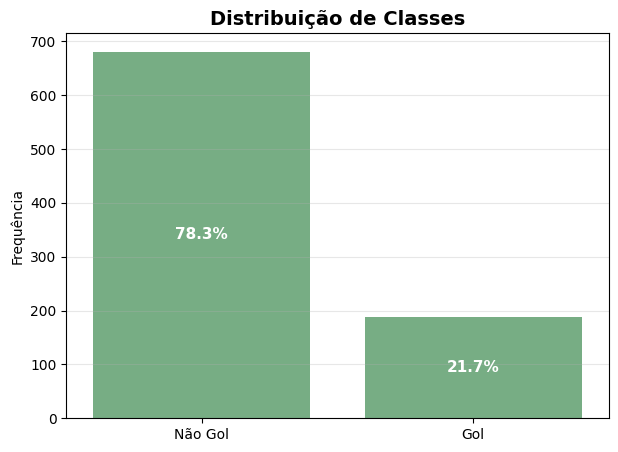

In [370]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x='goal',
    data=df,
    color='#6EB680'
)

# Calcula porcentagens
total = len(df)
for i, p in enumerate(ax.patches):
    porcentagem = 100 * p.get_height() / total

    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() / 2,  # Coloca no meio da barra
        f'{porcentagem:.1f}%',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='white'
    )

plt.title('Distribuição de Classes', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Não Gol', 'Gol'])
plt.ylabel('Frequência')
plt.xlabel('')
plt.grid(axis='y', alpha=0.3)
plt.show()

### **Análise distâncias**



In [371]:
# Função auxiliar para criar bins cobrindo todos os valores
def make_bins(series, step):
    min_val = series.min()
    max_val = series.max()
    return np.arange(
        np.floor(min_val / step) * step,
        np.ceil(max_val / step) * step + step,
        step
    )


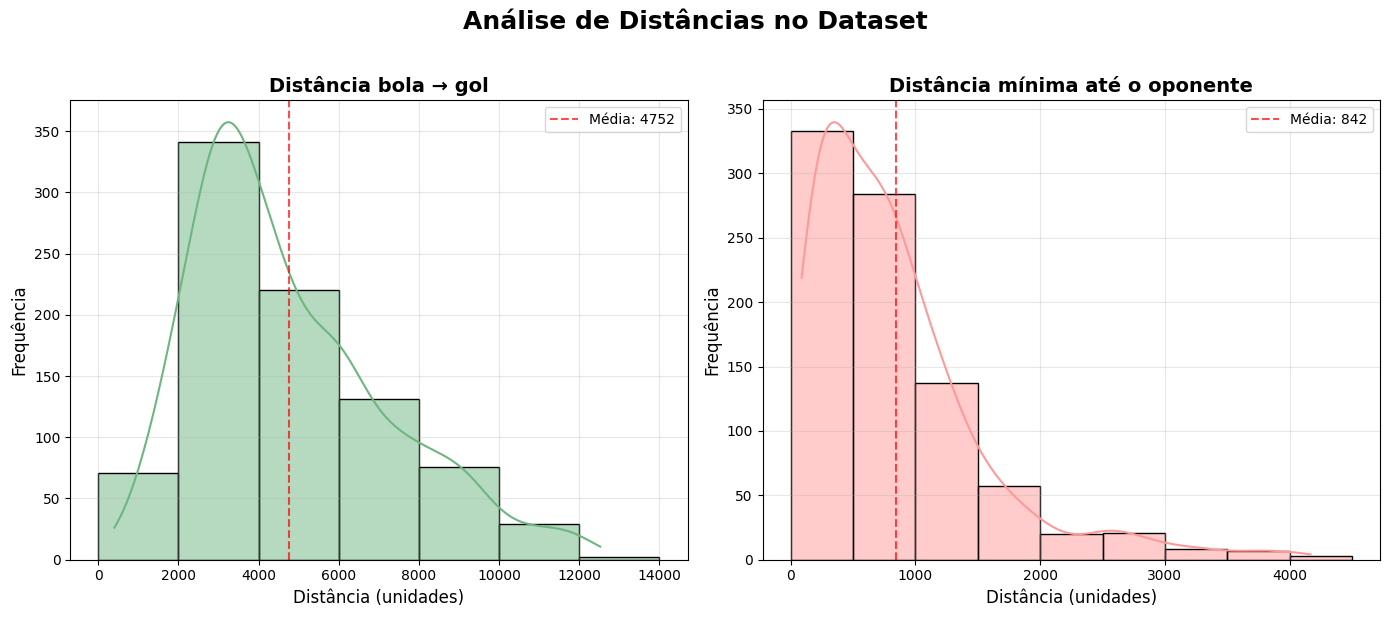

In [372]:
# Bins separados por variável
bins_goal = make_bins(df['feat_dist_goal'], step=2000)
bins_min_opponent = make_bins(df['feat_min_dist_opponent'], step=500)

# Cria subplots (1 linha, 2 colunas)
# Ajustei o figsize para (14, 6) que costuma ficar melhor para 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1 — feat_dist_goal (Primeiro gráfico - índice 0)
sns.histplot(
    data=df,
    x='feat_dist_goal',
    bins=bins_goal,
    ax=axes[0],  # CORREÇÃO: Usar apenas [0]
    color='#6EB680',
    kde=True
)
axes[0].set_title('Distância bola → gol', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_xlabel('Distância (unidades)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Estatísticas no gráfico 1
media1 = df['feat_dist_goal'].mean()
axes[0].axvline(media1, color='red', linestyle='--', alpha=0.7,
                  label=f'Média: {media1:.0f}')
axes[0].legend()

# 2 — feat_min_dist_opponent (Segundo gráfico - índice 1)
sns.histplot(
    data=df,
    x='feat_min_dist_opponent',
    bins=bins_min_opponent,
    ax=axes[1],  # CORREÇÃO: Usar apenas [1]
    color='#FF9999',
    kde=True
)
axes[1].set_title('Distância mínima até o oponente', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Frequência', fontsize=12)
axes[1].set_xlabel('Distância (unidades)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Estatísticas no gráfico 2
media2 = df['feat_min_dist_opponent'].mean()
axes[1].axvline(media2, color='red', linestyle='--', alpha=0.7,
                  label=f'Média: {media2:.0f}')
axes[1].legend()

# Título geral
plt.suptitle('Análise de Distâncias no Dataset', fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

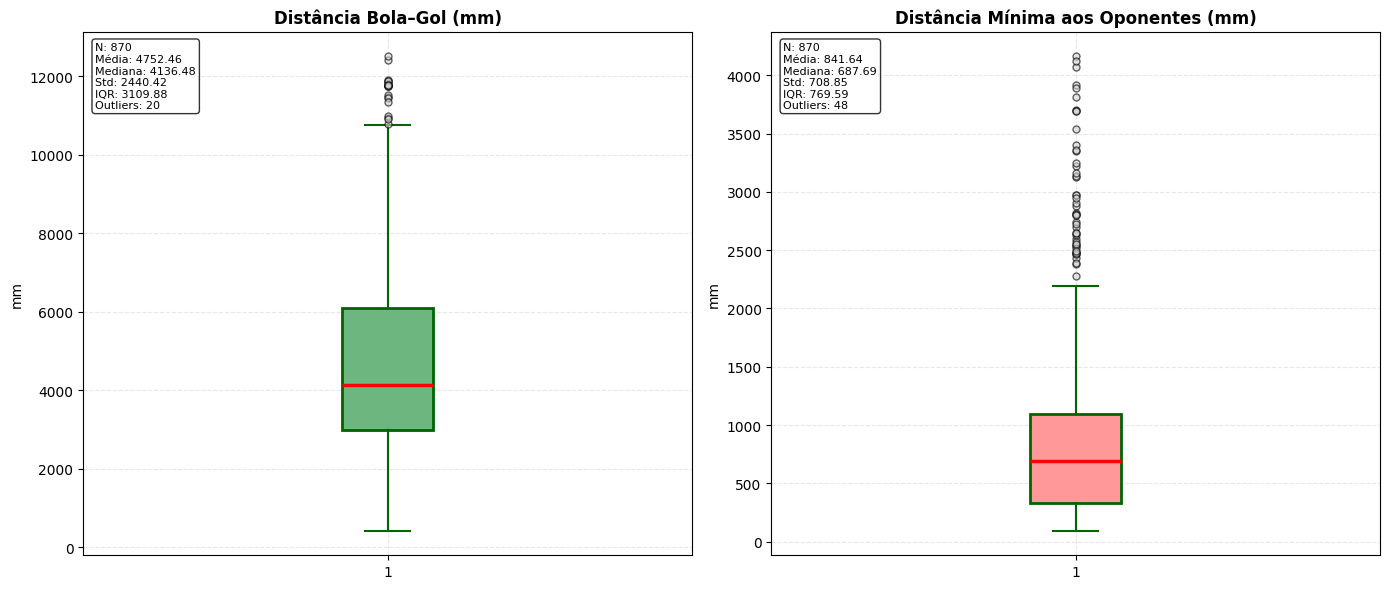

In [373]:
# Colunas solicitadas (agora com 4 colunas)
distance_cols_4 = [
    'feat_dist_goal',
    'feat_min_dist_opponent'
]

# Títulos detalhados (mantendo o mesmo formato)
titulos_pt_detalhados_4 = {
    'feat_dist_goal': 'Distância Bola–Gol (mm)',
    'feat_min_dist_opponent': 'Distância Mínima aos Oponentes (mm)'
}

# Layout 2x2 para 4 gráficos (ajustado de 1x3 para 2x2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()  # Achatar para iterar facilmente

for i, col in enumerate(distance_cols_4):
    if col not in df.columns:
        print(f"⚠️  Coluna '{col}' não encontrada no DataFrame")
        continue

    data = df[col].dropna()

    # Estatísticas (mantendo igual)
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    # Estilo dos boxplots (cores ajustadas para cada feature)
    # Definindo cores baseadas nos histogramas anteriores
    if col == 'feat_dist_goal':
        facecolor = '#6EB680'  # Verde do primeiro histograma
    elif col == 'feat_min_dist_opponent':
        facecolor = '#FF9999'  # Rosa do segundo histograma
    elif col == 'dist_goalkeeper_to_goal':
        facecolor = '#66B3FF'  # Azul do terceiro histograma
    elif col == 'dist_kicker_goalkeeper':
        facecolor = '#FFB366'  # Laranja do quarto histograma
    else:
        facecolor = '#6EB680'  # Padrão verde

    boxprops = dict(facecolor=facecolor, color='darkgreen', linewidth=2)
    medianprops = dict(color='red', linewidth=2.5)
    whiskerprops = dict(color='darkgreen', linewidth=1.5)
    capprops = dict(color='darkgreen', linewidth=1.5)

    # Boxplot (mantendo as mesmas opções)
    axes[i].boxplot(
        data,
        vert=True,
        patch_artist=True,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        flierprops=dict(marker='o', markerfacecolor='lightgray', markersize=5, alpha=0.6)
    )

    axes[i].set_title(titulos_pt_detalhados_4.get(col, col),
                      fontsize=12, fontweight='bold')
    axes[i].set_ylabel('mm', fontsize=10)
    axes[i].grid(True, alpha=0.3, linestyle='--')

    # Estatísticas escritas (formato igual)
    stats_text = (
        f'N: {len(data):,}\n'
        f'Média: {data.mean():.2f}\n'
        f'Mediana: {data.median():.2f}\n'
        f'Std: {data.std():.2f}\n'
        f'IQR: {IQR:.2f}\n'
        f'Outliers: {len(outliers)}'
    )

    axes[i].text(
        0.02, 0.98,
        stats_text,
        transform=axes[i].transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

plt.tight_layout()
plt.show()

### **Análise velocidade e aceleração**



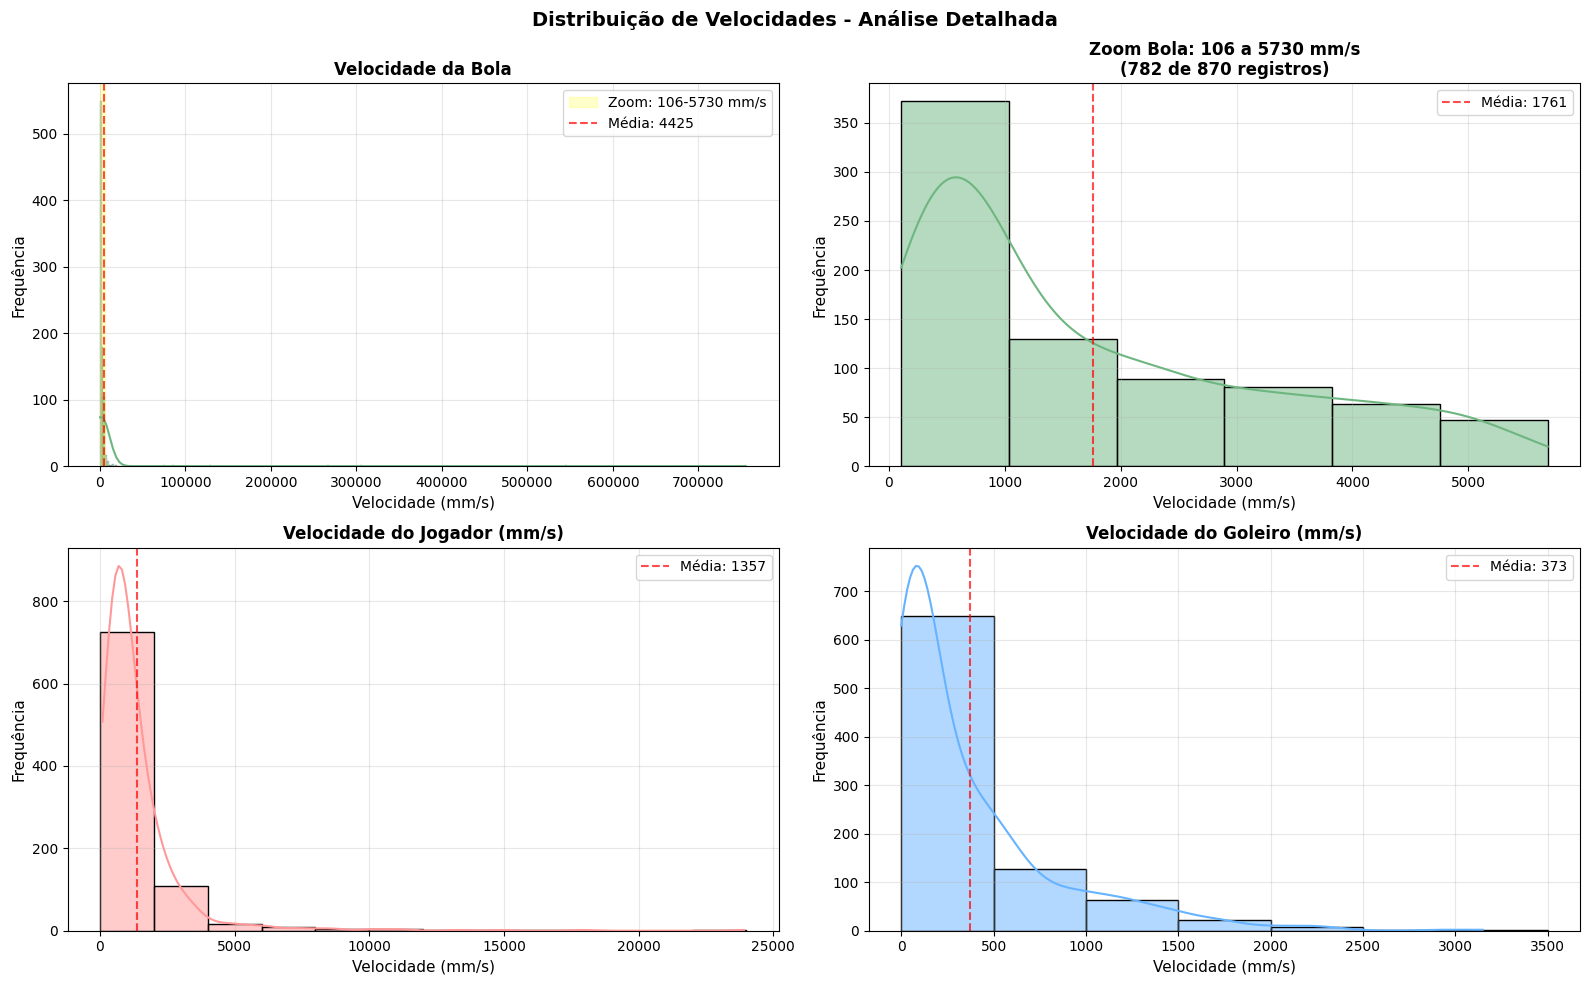

In [374]:
colors_vel = {
    'ball_velocity_norm': '#6EB680',
    'kicker_velocity_norm': '#FF9999',
    'goalkeeper_velocity_norm': '#66B3FF'
}

velocity_norm_cols = [
    'ball_velocity_norm',
    'kicker_velocity_norm',
    'goalkeeper_velocity_norm'
]

titulos_pt_detalhados_norm = {
    'ball_velocity_norm': 'Velocidade da Bola (mm/s)',
    'kicker_velocity_norm': 'Velocidade do Jogador (mm/s)',
    'goalkeeper_velocity_norm': 'Velocidade do Goleiro (mm/s)'
}

# Para a bola: histograma completo e zoom
data_bola = df['ball_velocity_norm'].dropna()

# Calcular área de zoom (P5-P95)
p5 = data_bola.quantile(0.05)
p95 = data_bola.quantile(0.95)

# Criar figura com 4 subplots (bola tem 2, outros 1 cada)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Ajustar layout dos subplots
# Bola: linha superior ocupa 2 colunas
ax_bola_completo = axes[0, 0]
ax_bola_zoom = axes[0, 1]
ax_kicker = axes[1, 0]
ax_gk = axes[1, 1]

# --- GRÁFICO 1: BOLA COMPLETA ---
bins_ball_completo = make_bins(data_bola, step=2000)
sns.histplot(data=data_bola, bins=bins_ball_completo,
             ax=ax_bola_completo, color=colors_vel['ball_velocity_norm'], kde=True)

# Destacar área de zoom
ax_bola_completo.axvspan(p5, p95, alpha=0.2, color='yellow',
                        label=f'Zoom: {p5:.0f}-{p95:.0f} mm/s')

media_bola = data_bola.mean()
ax_bola_completo.axvline(media_bola, color='red', linestyle='--', alpha=0.7,
                        label=f'Média: {media_bola:.0f}')
ax_bola_completo.legend()
ax_bola_completo.set_title('Velocidade da Bola', fontsize=12, fontweight='bold')
ax_bola_completo.set_xlabel('Velocidade (mm/s)', fontsize=11)
ax_bola_completo.set_ylabel('Frequência', fontsize=11)
ax_bola_completo.grid(True, alpha=0.3)

# --- GRÁFICO 2: ZOOM DA BOLA (P5-P95) ---
data_bola_zoom = data_bola[(data_bola >= p5) & (data_bola <= p95)]
# Ajustar step dos bins para o zoom
step_zoom = 500  # Mais detalhado no zoom
bins_ball_zoom = make_bins(data_bola_zoom, step=step_zoom)

sns.histplot(data=data_bola_zoom, bins=6,
             ax=ax_bola_zoom, color=colors_vel['ball_velocity_norm'], kde=True)

ax_bola_zoom.axvline(data_bola_zoom.mean(), color='red', linestyle='--', alpha=0.7,
                    label=f'Média: {data_bola_zoom.mean():.0f}')
ax_bola_zoom.legend()
ax_bola_zoom.set_title(f'Zoom Bola: {p5:.0f} a {p95:.0f} mm/s\n({len(data_bola_zoom)} de {len(data_bola)} registros)',
                      fontsize=12, fontweight='bold')
ax_bola_zoom.set_xlabel('Velocidade (mm/s)', fontsize=11)
ax_bola_zoom.set_ylabel('Frequência', fontsize=11)
ax_bola_zoom.grid(True, alpha=0.3)

# --- GRÁFICO 3: JOGADOR ---
data_kicker = df['kicker_velocity_norm'].dropna()
bins_kicker = make_bins(data_kicker, step=2000)
sns.histplot(data=data_kicker, bins=bins_kicker,
             ax=ax_kicker, color=colors_vel['kicker_velocity_norm'], kde=True)

ax_kicker.axvline(data_kicker.mean(), color='red', linestyle='--', alpha=0.7,
                 label=f'Média: {data_kicker.mean():.0f}')
ax_kicker.legend()
ax_kicker.set_title('Velocidade do Jogador (mm/s)', fontsize=12, fontweight='bold')
ax_kicker.set_xlabel('Velocidade (mm/s)', fontsize=11)
ax_kicker.set_ylabel('Frequência', fontsize=11)
ax_kicker.grid(True, alpha=0.3)

# --- GRÁFICO 4: GOLEIRO ---
data_gk = df['goalkeeper_velocity_norm'].dropna()
bins_gk = make_bins(data_gk, step=500)
sns.histplot(data=data_gk, bins=bins_gk,
             ax=ax_gk, color=colors_vel['goalkeeper_velocity_norm'], kde=True)

ax_gk.axvline(data_gk.mean(), color='red', linestyle='--', alpha=0.7,
             label=f'Média: {data_gk.mean():.0f}')
ax_gk.legend()
ax_gk.set_title('Velocidade do Goleiro (mm/s)', fontsize=12, fontweight='bold')
ax_gk.set_xlabel('Velocidade (mm/s)', fontsize=11)
ax_gk.set_ylabel('Frequência', fontsize=11)
ax_gk.grid(True, alpha=0.3)

plt.suptitle('Distribuição de Velocidades - Análise Detalhada', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

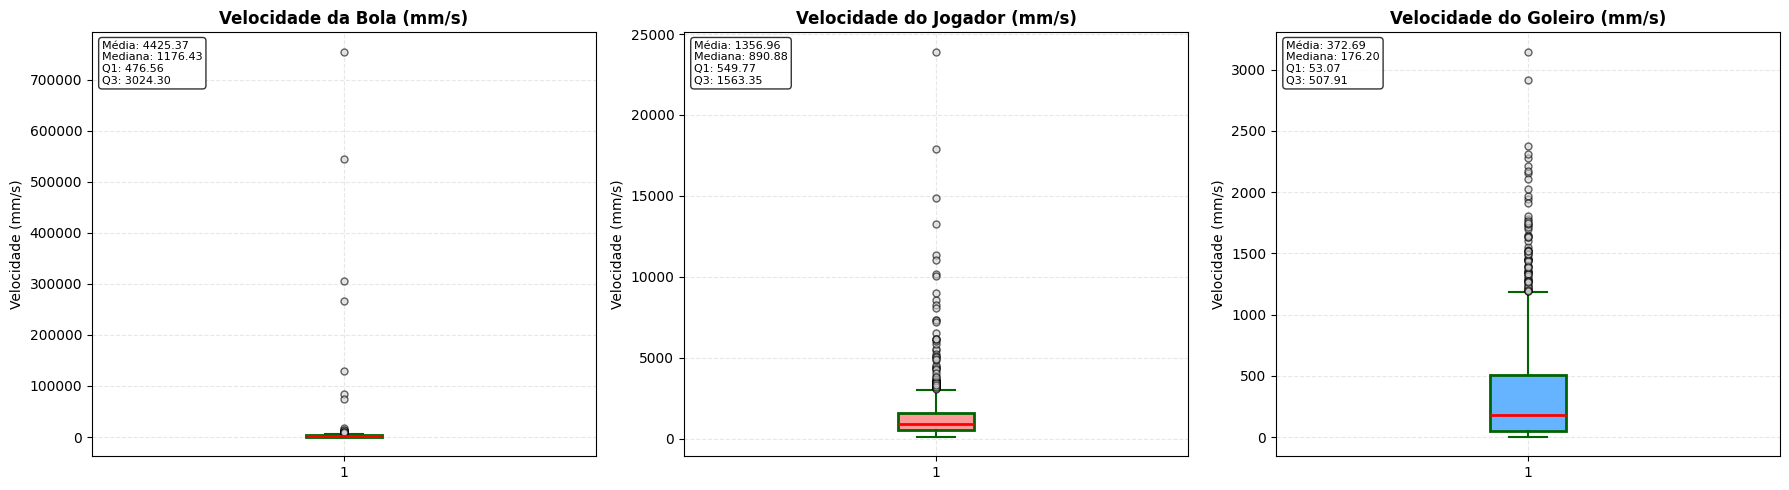

In [375]:
# Mantém apenas as velocidades norm (normas)
velocity_norm_cols = [
    'ball_velocity_norm',
    'kicker_velocity_norm',
    'goalkeeper_velocity_norm'
]

# Títulos traduzidos
titulos_norm = {
    'ball_velocity_norm': 'Velocidade da Bola (mm/s)',
    'kicker_velocity_norm': 'Velocidade do Jogador (mm/s)',
    'goalkeeper_velocity_norm': 'Velocidade do Goleiro (mm/s)'
}

# Layout 1x3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, col in enumerate(velocity_norm_cols):
    data = df[col].dropna()

    # Estilo do boxplot
    boxprops = dict(facecolor= colors_vel[col], color='darkgreen', linewidth=2)
    medianprops = dict(color='red', linewidth=2)
    whiskerprops = dict(color='darkgreen', linewidth=1.5)
    capprops = dict(color='darkgreen', linewidth=1.5)

    axes[i].boxplot(
        data,
        vert=True,
        patch_artist=True,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        flierprops=dict(
            marker='o',
            markerfacecolor='lightgray',
            markersize=5,
            alpha=0.6
        )
    )

    # Título
    axes[i].set_title(titulos_norm[col], fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Velocidade (mm/s)', fontsize=10)
    axes[i].grid(True, alpha=0.3, linestyle='--')

    # Texto com estatísticas
    stats_text = (
        f'Média: {data.mean():.2f}\n'
        f'Mediana: {data.median():.2f}\n'
        f'Q1: {np.percentile(data, 25):.2f}\n'
        f'Q3: {np.percentile(data, 75):.2f}'
    )

    axes[i].text(
        0.02, 0.98,
        stats_text,
        transform=axes[i].transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

plt.tight_layout()
plt.show()


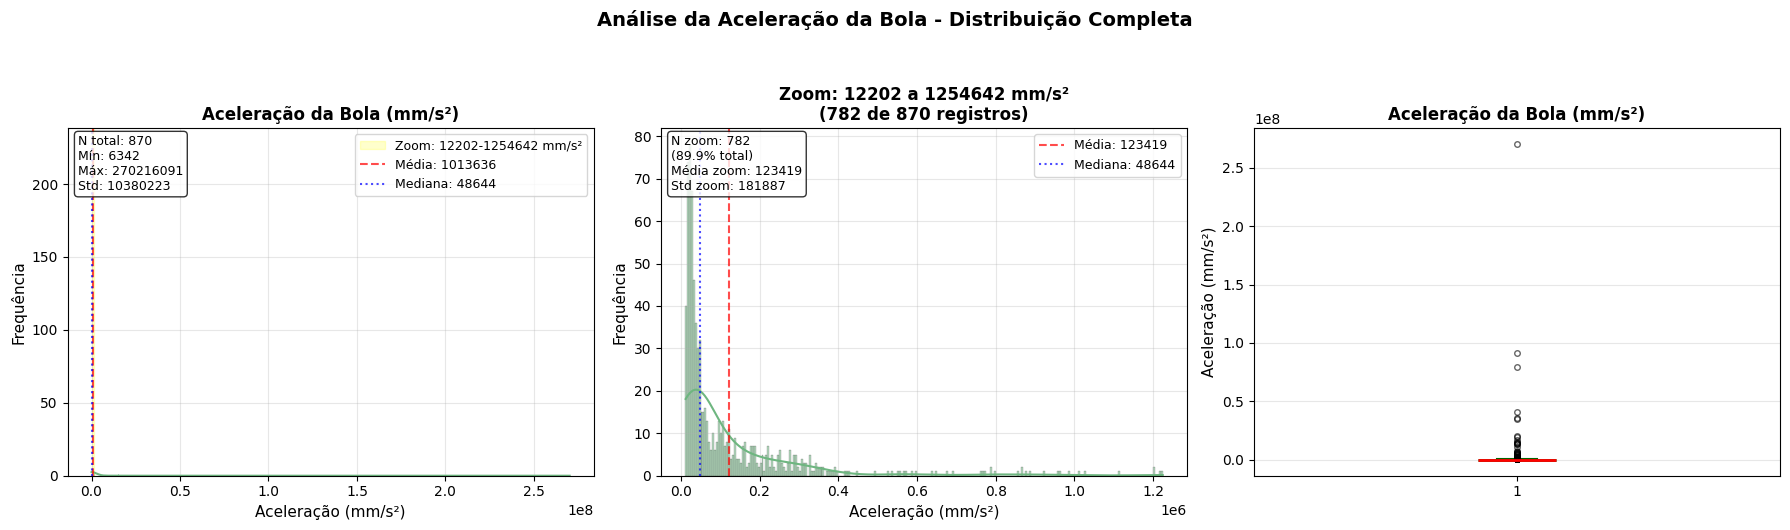

In [376]:
# Configurações para a aceleração da bola
color_acc = '#6EB680'
data_acc = df['ball_acceleration_norm'].dropna()

# Calcular área de zoom (P5-P95) e estatísticas
p5 = data_acc.quantile(0.05)
p95 = data_acc.quantile(0.95)
media_total = data_acc.mean()
mediana_total = data_acc.median()

# Criar figura com 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- GRÁFICO 1: HISTOGRAMA COMPLETO ---
bins_completo = make_bins(data_acc, step=20000)
sns.histplot(data=data_acc, bins=bins_completo,
             ax=ax1, color=color_acc, kde=True)

# Destacar área de zoom
ax1.axvspan(p5, p95, alpha=0.2, color='yellow',
           label=f'Zoom: {p5:.0f}-{p95:.0f} mm/s²')

ax1.axvline(media_total, color='red', linestyle='--', alpha=0.7,
           label=f'Média: {media_total:.0f}')
ax1.axvline(mediana_total, color='blue', linestyle=':', alpha=0.7,
           label=f'Mediana: {mediana_total:.0f}')
ax1.legend(fontsize=9)
ax1.set_title('Aceleração da Bola (mm/s²)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Aceleração (mm/s²)', fontsize=11)
ax1.set_ylabel('Frequência', fontsize=11)
ax1.grid(True, alpha=0.3)

# Adicionar estatísticas no gráfico 1
stats_text1 = (
    f"N total: {len(data_acc):,}\n"
    f"Mín: {data_acc.min():.0f}\n"
    f"Máx: {data_acc.max():.0f}\n"
    f"Std: {data_acc.std():.0f}"
)
ax1.text(0.02, 0.98, stats_text1,
         transform=ax1.transAxes,
         fontsize=9,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- GRÁFICO 2: ZOOM (P5-P95) ---
data_zoom = data_acc[(data_acc >= p5) & (data_acc <= p95)]
step_zoom = 5000
bins_zoom = make_bins(data_zoom, step=step_zoom)

sns.histplot(data=data_zoom, bins=bins_zoom,
             ax=ax2, color=color_acc, kde=True)

media_zoom = data_zoom.mean()
mediana_zoom = data_zoom.median()
ax2.axvline(media_zoom, color='red', linestyle='--', alpha=0.7,
           label=f'Média: {media_zoom:.0f}')
ax2.axvline(mediana_zoom, color='blue', linestyle=':', alpha=0.7,
           label=f'Mediana: {mediana_zoom:.0f}')
ax2.legend(fontsize=9)
ax2.set_title(f'Zoom: {p5:.0f} a {p95:.0f} mm/s²\n'
             f'({len(data_zoom):,} de {len(data_acc):,} registros)',
             fontsize=12, fontweight='bold')
ax2.set_xlabel('Aceleração (mm/s²)', fontsize=11)
ax2.set_ylabel('Frequência', fontsize=11)
ax2.grid(True, alpha=0.3)

# Adicionar estatísticas no gráfico 2
stats_text2 = (
    f"N zoom: {len(data_zoom):,}\n"
    f"({len(data_zoom)/len(data_acc)*100:.1f}% total)\n"
    f"Média zoom: {media_zoom:.0f}\n"
    f"Std zoom: {data_zoom.std():.0f}"
)
ax2.text(0.02, 0.98, stats_text2,
         transform=ax2.transAxes,
         fontsize=9,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- GRÁFICO 3: BOXPLOT ---
boxplot_elements = ax3.boxplot(
    data_acc,
    vert=True,
    patch_artist=True,
    showfliers=True
)

# Colorir o boxplot
boxplot_elements['boxes'][0].set_facecolor(color_acc)
boxplot_elements['boxes'][0].set_edgecolor('darkgreen')
boxplot_elements['boxes'][0].set_linewidth(2)

# Configurar mediana
boxplot_elements['medians'][0].set_color('red')
boxplot_elements['medians'][0].set_linewidth(2)

# Configurar whiskers e caps
for whisker in boxplot_elements['whiskers']:
    whisker.set_color('darkgreen')
    whisker.set_linewidth(1.5)

for cap in boxplot_elements['caps']:
    cap.set_color('darkgreen')
    cap.set_linewidth(1.5)

# Configurar outliers
boxplot_elements['fliers'][0].set(marker='o', color='gray',
                                   alpha=0.6, markersize=4)

ax3.set_title('Aceleração da Bola (mm/s²)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Aceleração (mm/s²)', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# Adicionar estatísticas detalhadas no boxplot
q1, q3 = np.percentile(data_acc, [25, 75])
iqr = q3 - q1
outliers = ((data_acc < (q1 - 1.5 * iqr)) | (data_acc > (q3 + 1.5 * iqr))).sum()

stats_text3 = (
    f"Mediana: {mediana_total:.0f}\n"
    f"Q1: {q1:.0f}\n"
    f"Q3: {q3:.0f}\n"
    f"IQR: {iqr:.0f}\n"
    f"Outliers: {outliers:,}\n"
    f"({outliers/len(data_acc)*100:.1f}%)"
)


# Ajustar layout
plt.suptitle('Análise da Aceleração da Bola - Distribuição Completa',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


###**Análise demais features calculadas**

In [377]:
df['feat_visible_angle'] = df['feat_visible_angle'].apply(lambda x: x - 360 if x > 180 else x)

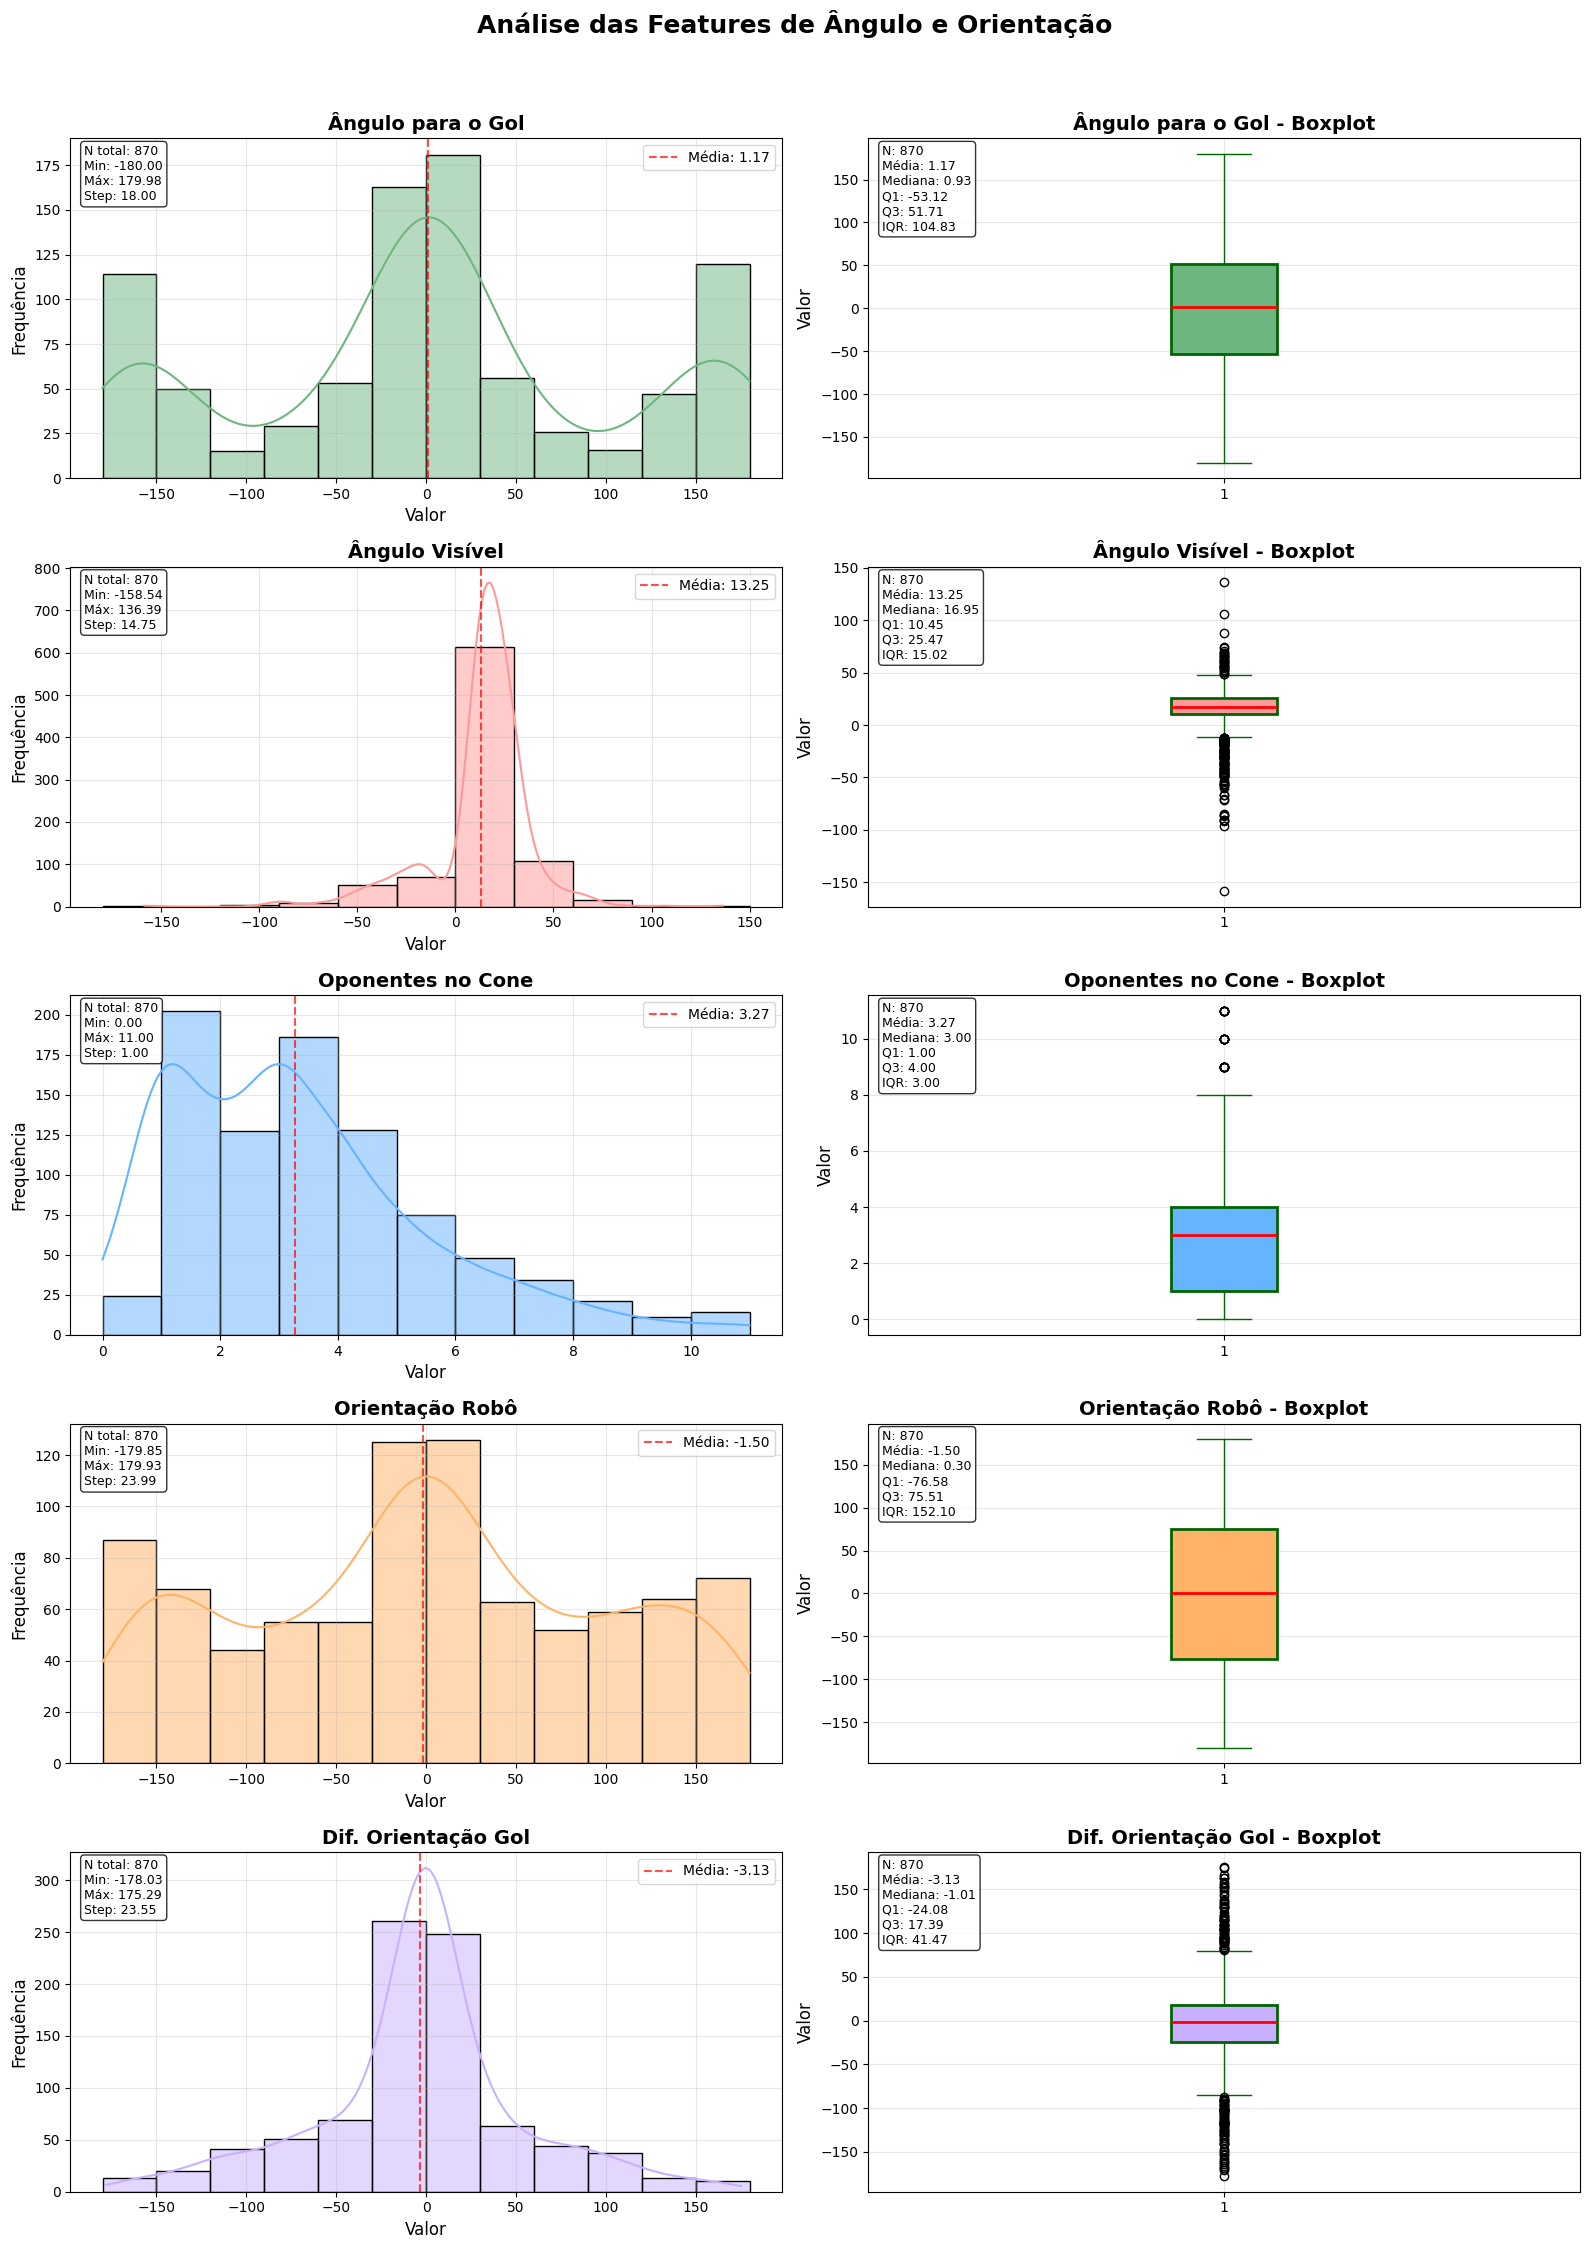

In [378]:
# Features solicitadas
feat_cols = {
    'feat_angle_goal': 'Ângulo para o Gol',
    'feat_visible_angle': 'Ângulo Visível',
    'feat_opponents_in_cone': 'Oponentes no Cone',
    'feat_robot_orientation': 'Orientação Robô',
    'feat_orientation_to_goal_diff': 'Dif. Orientação Gol'
}

fig, axes = plt.subplots(len(feat_cols), 2, figsize=(16, 22))

# Cores para cada variável
colors = ['#6EB680', '#FF9999', '#66B3FF', '#FFB366', '#C9AFFF']

for row, ((col, titulo), color) in enumerate(zip(feat_cols.items(), colors)):
    data = df[col].dropna()

    # ----------------------------------------------------------
    # 1) HISTOGRAMA com bins personalizados - igual aos outros gráficos
    # ----------------------------------------------------------
    # Definir passo apropriado para cada tipo de variável
    if 'angle' in col.lower():
        # Para ângulos (geralmente em radianos ou graus)
        step = (data.max() - data.min()) / 20  # 20 bins
        bins = make_bins(data, step=30)
    elif 'opponents' in col.lower():
        # Variável discreta (contagem de oponentes)
        step = 1
        bins = make_bins(data, step=step)
    elif 'orientation' in col.lower():
        # Para orientações (geralmente em radianos)
        step = (data.max() - data.min()) / 15  # 15 bins
        bins = make_bins(data, step=30)
    else:
        # Para diferenças de orientação
        step = (data.max() - data.min()) / 20
        bins = make_bins(data, step=step)

    # Histograma com bins específicos
    sns.histplot(
        data=df,
        x=col,
        bins=bins,
        ax=axes[row, 0],
        color=color,
        kde=True
    )

    axes[row, 0].set_title(titulo, fontsize=14, fontweight='bold')
    axes[row, 0].set_ylabel('Frequência', fontsize=12)
    axes[row, 0].set_xlabel('Valor', fontsize=12)
    axes[row, 0].grid(True, alpha=0.3)

    # Adicionar linhas de média
    media = data.mean()
    mediana = data.median()
    axes[row, 0].axvline(media, color='red', linestyle='--', alpha=0.7,
                        label=f'Média: {media:.2f}')
    axes[row, 0].legend(fontsize=10)

    # Adicionar texto com informações (como nos outros gráficos)
    info_text = (
        f"N total: {len(data):,}\n"
        f"Min: {data.min():.2f}\n"
        f"Máx: {data.max():.2f}\n"
        f"Step: {step:.2f}"
    )

    axes[row, 0].text(
        0.02, 0.98, info_text,
        transform=axes[row, 0].transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    # ----------------------------------------------------------
    # 2) BOXPLOT com estatísticas detalhadas
    # ----------------------------------------------------------
    boxplot_elements = axes[row, 1].boxplot(
        data,
        vert=True,
        patch_artist=True
    )

    # Colorir a caixa
    boxplot_elements['boxes'][0].set_facecolor(color)
    boxplot_elements['boxes'][0].set_edgecolor('darkgreen')
    boxplot_elements['boxes'][0].set_linewidth(2)

    # Configurar medianas e whiskers
    boxplot_elements['medians'][0].set_color('red')
    boxplot_elements['medians'][0].set_linewidth(2)
    boxplot_elements['whiskers'][0].set_color('darkgreen')
    boxplot_elements['whiskers'][1].set_color('darkgreen')
    boxplot_elements['caps'][0].set_color('darkgreen')
    boxplot_elements['caps'][1].set_color('darkgreen')

    axes[row, 1].set_title(f"{titulo} - Boxplot", fontsize=14, fontweight='bold')
    axes[row, 1].set_ylabel('Valor', fontsize=12)
    axes[row, 1].grid(True, alpha=0.3)

    # Adicionar estatísticas detalhadas
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_whisker = max(data.min(), q1 - 1.5 * iqr)
    upper_whisker = min(data.max(), q3 + 1.5 * iqr)

    stats_text = (
        f"N: {len(data):,}\n"
        f"Média: {media:.2f}\n"
        f"Mediana: {mediana:.2f}\n"
        f"Q1: {q1:.2f}\n"
        f"Q3: {q3:.2f}\n"
        f"IQR: {iqr:.2f}"
    )

    axes[row, 1].text(
        0.02, 0.98, stats_text,
        transform=axes[row, 1].transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

plt.suptitle('Análise das Features de Ângulo e Orientação', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Correlações

In [379]:
df.columns

Index(['ball_velocity_norm', 'ball_acceleration_norm', 'kicker_velocity_norm',
       'goalkeeper_velocity_norm', 'feat_dist_goal', 'feat_angle_goal',
       'feat_visible_angle', 'feat_min_dist_opponent',
       'feat_opponents_in_cone', 'feat_robot_orientation',
       'feat_orientation_to_goal_diff', 'goal'],
      dtype='object')

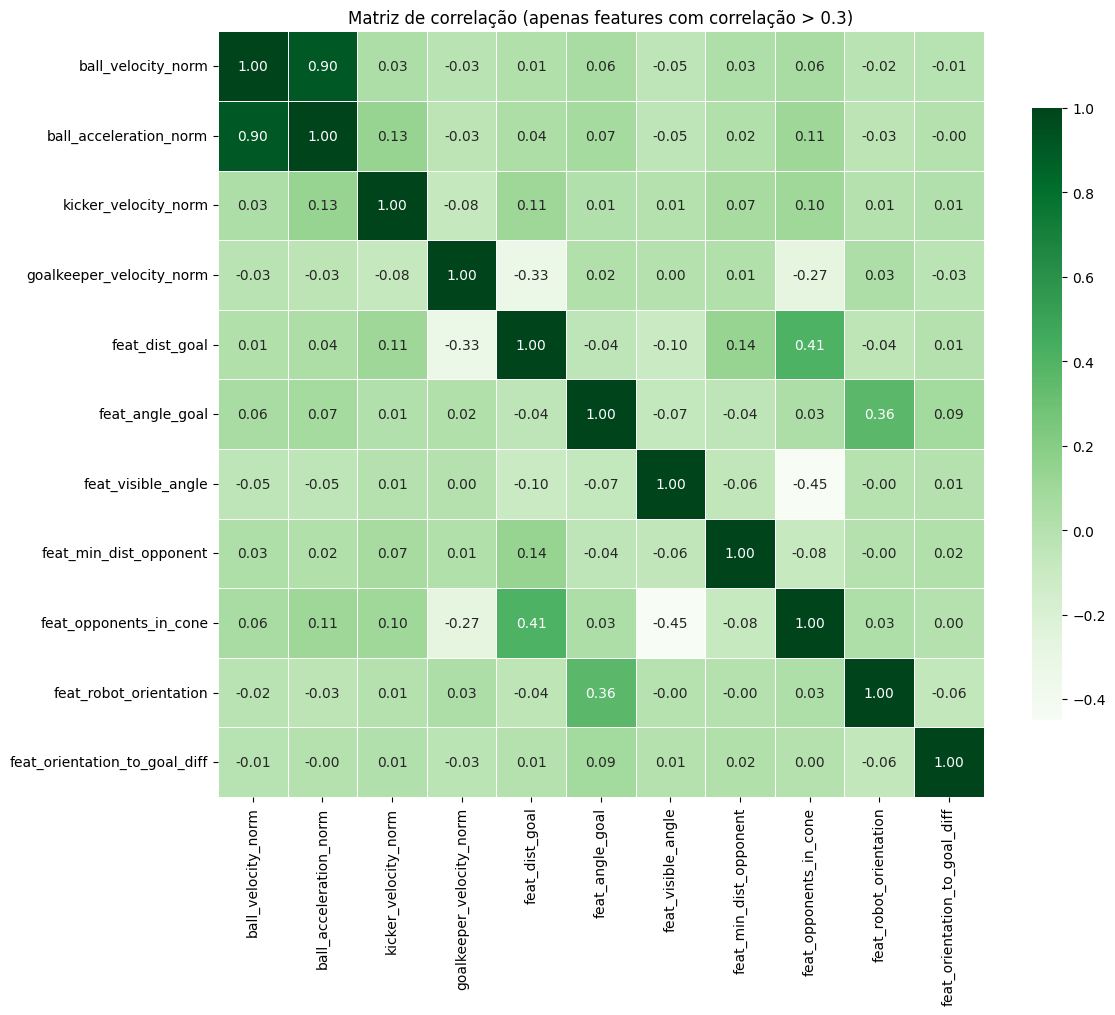

In [380]:
# Correlação absoluta com a variável alvo
features_to_corr = df.columns.tolist()
features_to_corr.remove('goal' )


# Definir threshold
threshold = 0.3

# Calcular matriz de correlação absoluta
corr_matrix = df[features_to_corr].corr()
# Plot com paleta Greens
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', square=True,
            linewidths=0.5, cmap='Greens',  # Paleta Greens
            cbar_kws={"shrink": 0.8})
plt.title(f'Matriz de correlação (apenas features com correlação > {threshold})')
plt.tight_layout()
plt.show()

In [381]:
corr_matrix = df.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]
df_reduced = df.drop(columns=to_drop)

print("Dropped features:", to_drop)

Dropped features: ['ball_acceleration_norm']


In [382]:
X = df.drop('goal', axis=1)
y = df['goal']

# Todas as features

## Regressão Logística

Fitting 5 folds for each of 10 candidates, totalling 50 fits
MELHOR SCORE (CV): 0.825652559928973
MELHORES PARÂMETROS:
  clf__C: 1
  clf__class_weight: balanced

TODAS AS FEATURES SELECIONADAS (11):
['ball_velocity_norm', 'ball_acceleration_norm', 'kicker_velocity_norm', 'goalkeeper_velocity_norm', 'feat_dist_goal', 'feat_angle_goal', 'feat_visible_angle', 'feat_min_dist_opponent', 'feat_opponents_in_cone', 'feat_robot_orientation', 'feat_orientation_to_goal_diff']

MELHOR THRESHOLD: 0.500
F1-SCORE (CV) com este threshold: 0.5644

AVALIAÇÃO FINAL NO CONJUNTO DE TESTE

MATRIZ DE CONFUSÃO:


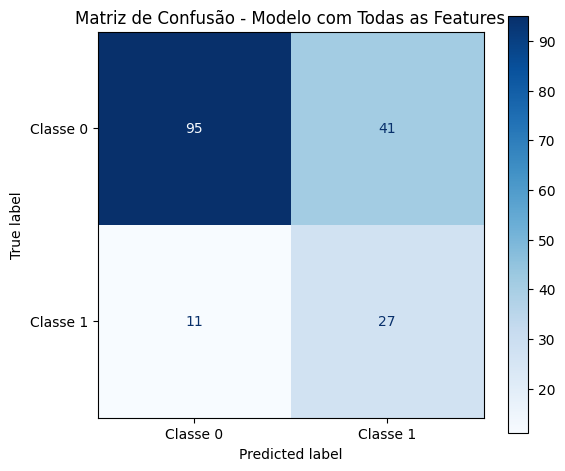


RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       136
           1       0.40      0.71      0.51        38

    accuracy                           0.70       174
   macro avg       0.65      0.70      0.65       174
weighted avg       0.79      0.70      0.72       174


ROC-AUC: 0.7419


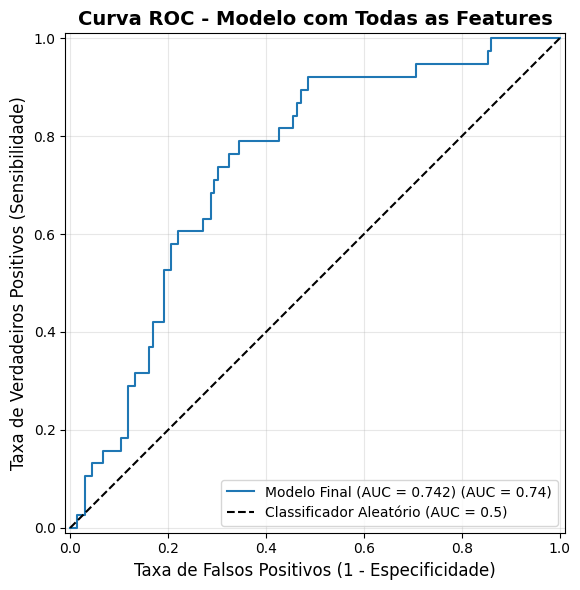


FEATURES UTILIZADAS NO MODELO (11):
 1. ball_velocity_norm
 2. ball_acceleration_norm
 3. kicker_velocity_norm
 4. goalkeeper_velocity_norm
 5. feat_dist_goal
 6. feat_angle_goal
 7. feat_visible_angle
 8. feat_min_dist_opponent
 9. feat_opponents_in_cone
10. feat_robot_orientation
11. feat_orientation_to_goal_diff


In [383]:
# 1. SEPARAÇÃO INICIAL
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. PIPELINE SIMPLIFICADO (SEM SELEÇÃO DE FEATURES)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        random_state=42,
        max_iter=5000,
        solver='liblinear'
    ))
])

# 3. GRADE DE HIPERPARÂMETROS SIMPLIFICADA
param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10],
    'clf__class_weight': [None, 'balanced']
}

# 4. GRID SEARCH COM VALIDAÇÃO CRUZADA
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True  # IMPORTANTE: re-treina com todos os dados
)

grid.fit(X_train, y_train)

# 5. MELHORES PARÂMETROS
print("=" * 60)
print("MELHOR SCORE (CV):", grid.best_score_)
print("MELHORES PARÂMETROS:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nTODAS AS FEATURES SELECIONADAS ({X.shape[1]}):")
print(X.columns.tolist())

# 7. TUNING DE THRESHOLD NO CONJUNTO DE TREINO (com validação cruzada)
def find_best_threshold(model, X, y, cv_splits=5):
    """Encontra o melhor threshold usando validação cruzada"""

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        # Re-treinar no fold de treino
        model.fit(X_train_cv, y_train_cv)
        y_probs = model.predict_proba(X_val_cv)[:, 1]

        # Avaliar cada threshold
        fold_scores = []
        for th in thresholds:
            y_pred = (y_probs >= th).astype(int)
            # ✅ CORREÇÃO: Usar F1-score para predições binárias
            score = f1_score(y_val_cv, y_pred, zero_division=0)
            fold_scores.append(score)

        best_scores.append(fold_scores)

    # Média entre folds
    mean_scores = np.mean(best_scores, axis=0)
    best_idx = np.argmax(mean_scores)
    best_threshold = thresholds[best_idx]

    return best_threshold, mean_scores[best_idx]

# Encontrar melhor threshold
threshold_vencedor, threshold_score = find_best_threshold(
    grid.best_estimator_, X_train, y_train, cv_splits=5
)
print(f"\nMELHOR THRESHOLD: {threshold_vencedor:.3f}")
print(f"F1-SCORE (CV) com este threshold: {threshold_score:.4f}")

# 8. MODELO FINAL (treinado com TODOS os dados de treino)
# O grid.best_estimator_ já está treinado com refit=True
modelo_final = grid.best_estimator_

# 9. PREDIÇÕES NO TESTE
y_probs_test = modelo_final.predict_proba(X_test)[:, 1]
predicoes_finais = (y_probs_test >= threshold_vencedor).astype(int)

# 10. AVALIAÇÃO FINAL
print("\n" + "=" * 60)
print("AVALIAÇÃO FINAL NO CONJUNTO DE TESTE")
print("=" * 60)

print("\nMATRIZ DE CONFUSÃO:")
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicoes_finais,
    display_labels=['Classe 0', 'Classe 1'],
    cmap='Blues',
    ax=ax,
    values_format='d'
)

ax.set_title('Matriz de Confusão - Modelo com Todas as Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nRELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, predicoes_finais))

auc_test = roc_auc_score(y_test, y_probs_test)  # CORRIGIDO: definir auc_test
print(f"\nROC-AUC: {auc_test:.4f}")

# 11. VISUALIZAÇÕES - APENAS CURVA ROC
fig, ax = plt.subplots(figsize=(8, 6))

# Curva ROC
RocCurveDisplay.from_estimator(
    modelo_final,
    X_test,
    y_test,
    ax=ax,
    name=f'Modelo Final (AUC = {auc_test:.3f})'
)

# Linha de referência (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório (AUC = 0.5)')

# Detalhes do gráfico
ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
ax.set_title('Curva ROC - Modelo com Todas as Features', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.show()

# 12. INFORMAÇÕES DAS FEATURES
print(f"\nFEATURES UTILIZADAS NO MODELO ({X.shape[1]}):")
for i, feat in enumerate(X.columns, 1):
    print(f"{i:2d}. {feat}")

## Árvore de Decisão

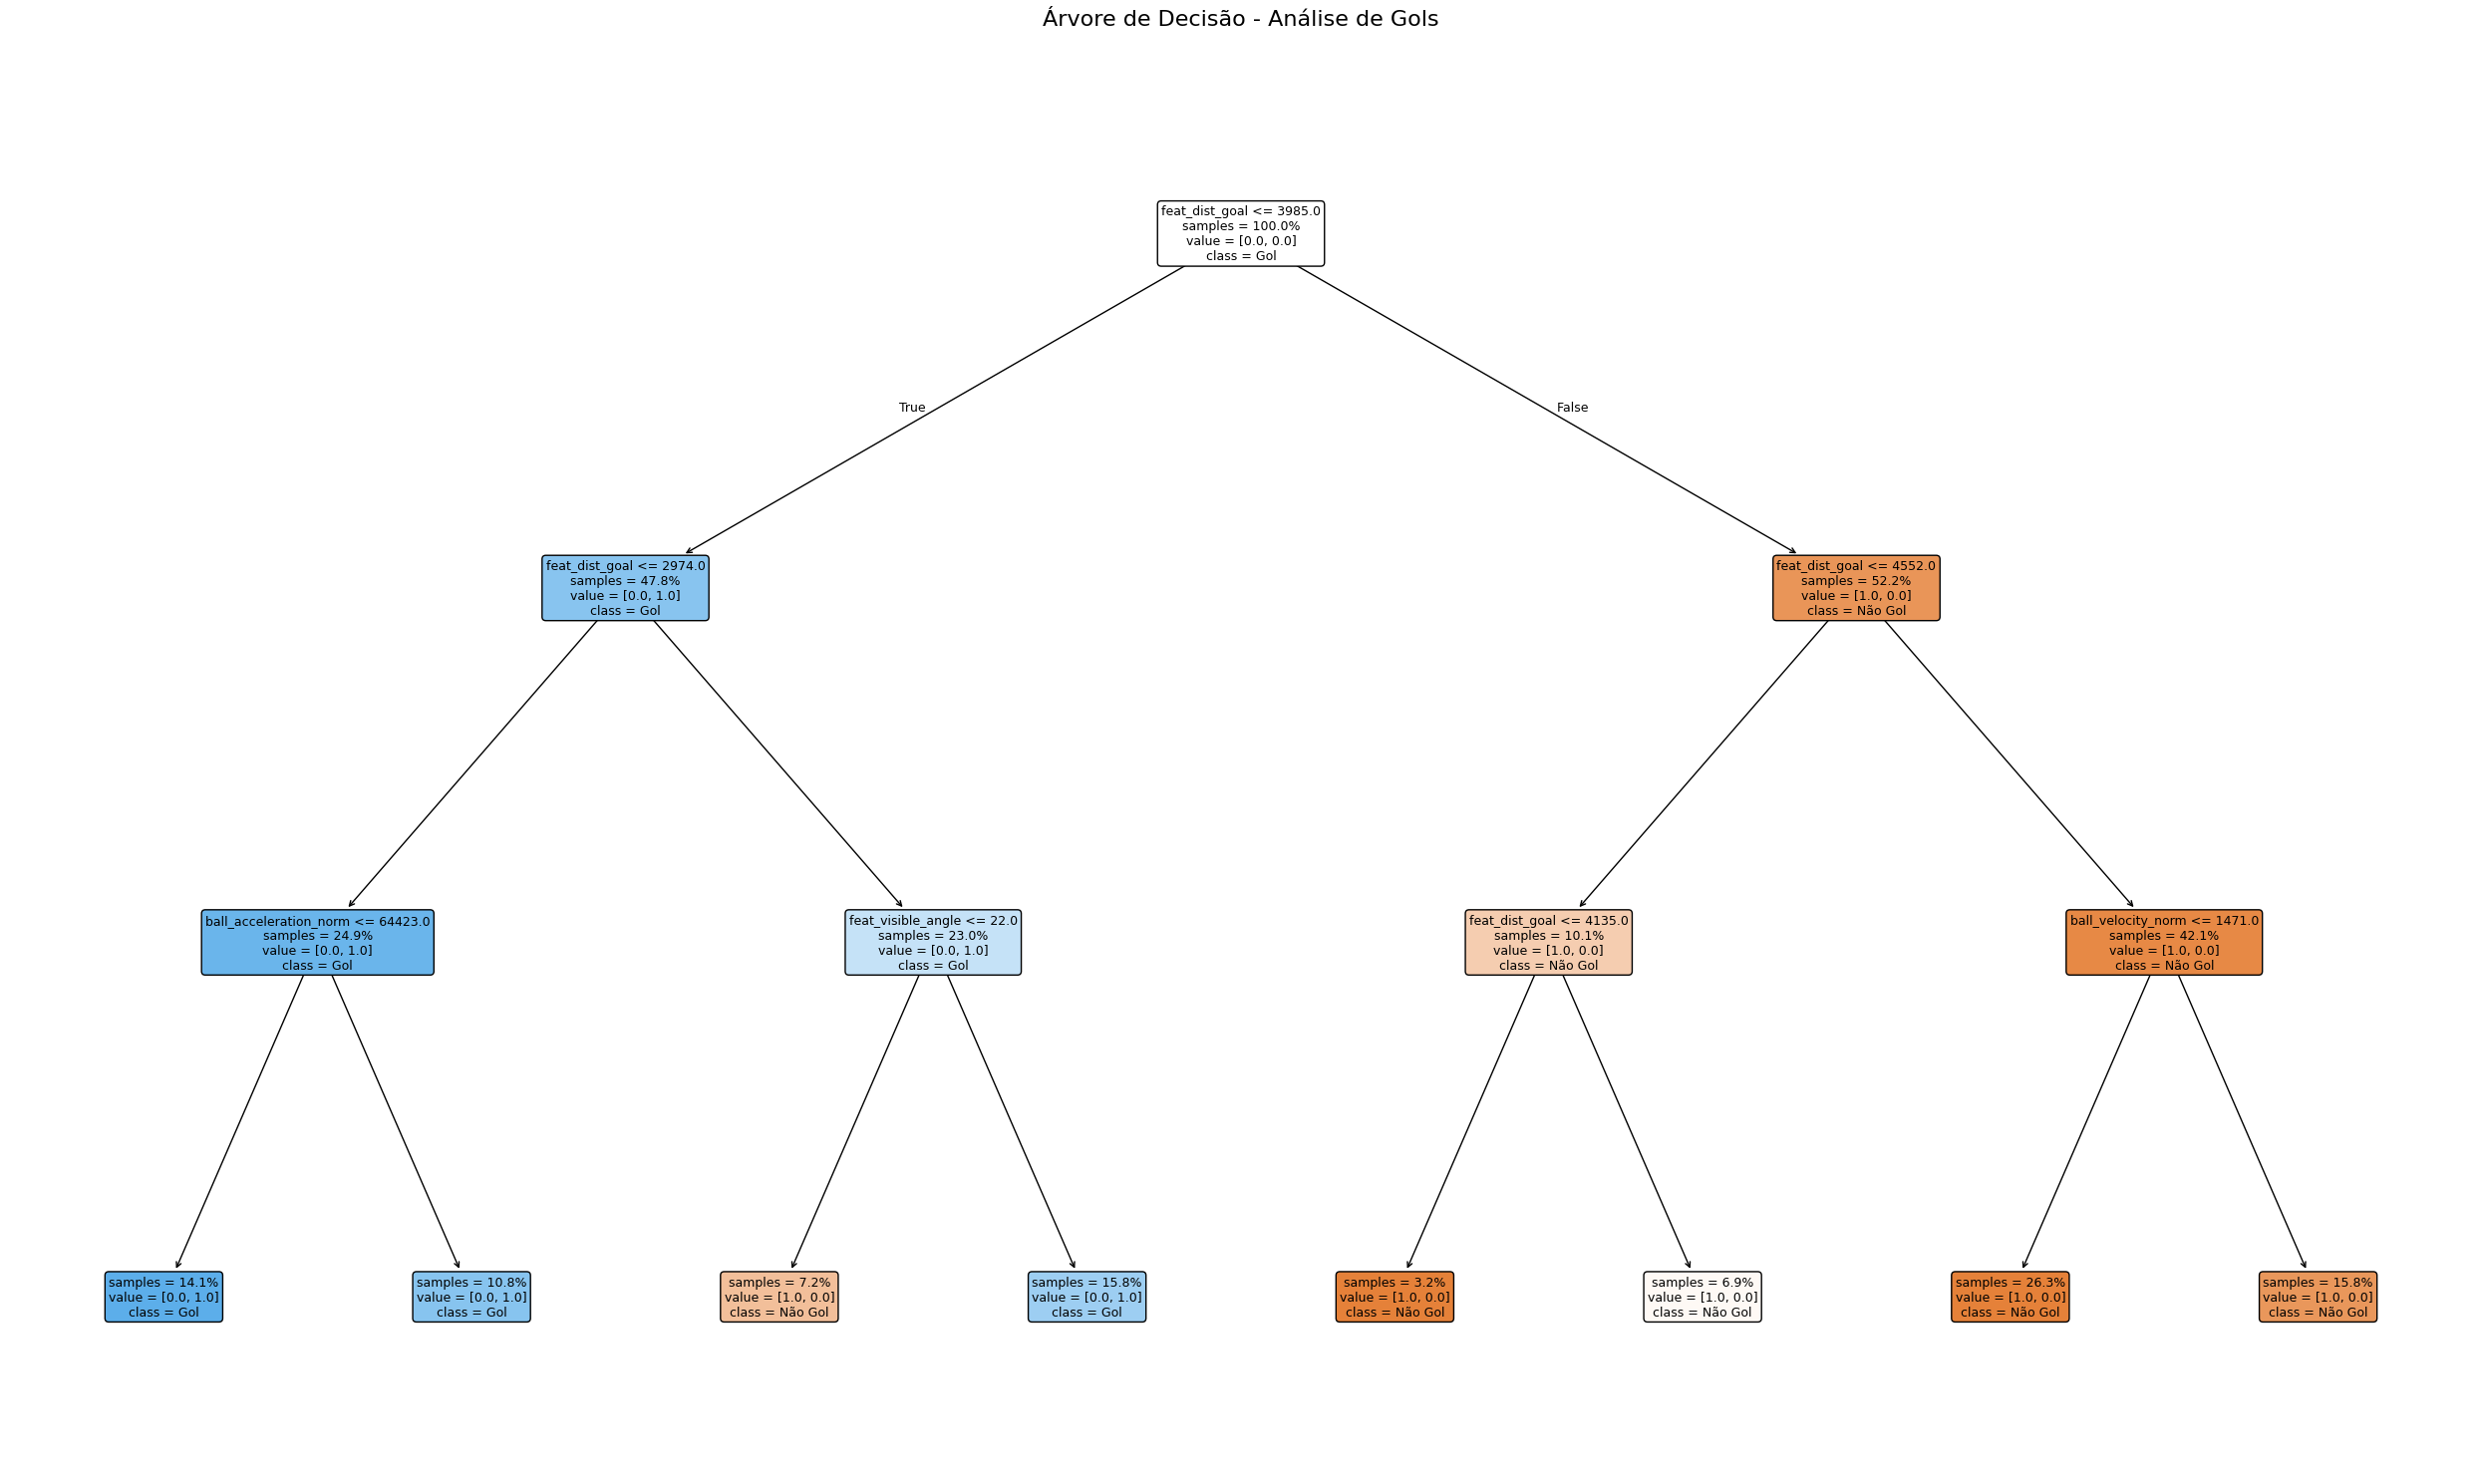

In [384]:
# Treinar a árvore
dt_model_selected = DecisionTreeClassifier(
    max_depth=3,
    criterion = 'gini',
    min_samples_leaf= 14,
    class_weight='balanced',
    random_state=42,

)

dt_model_selected.fit(X_train, y_train)

# Plotar a árvore
plt.figure(figsize=(25, 15))

plot_tree(dt_model_selected,
          feature_names=X.columns,
          class_names=['Não Gol', 'Gol'],
          filled=True,
          rounded=True,
          fontsize=9,
          impurity=False,
          proportion=True,
          precision=0)

plt.title("Árvore de Decisão - Análise de Gols\n", fontsize=16)
plt.tight_layout()
plt.show()


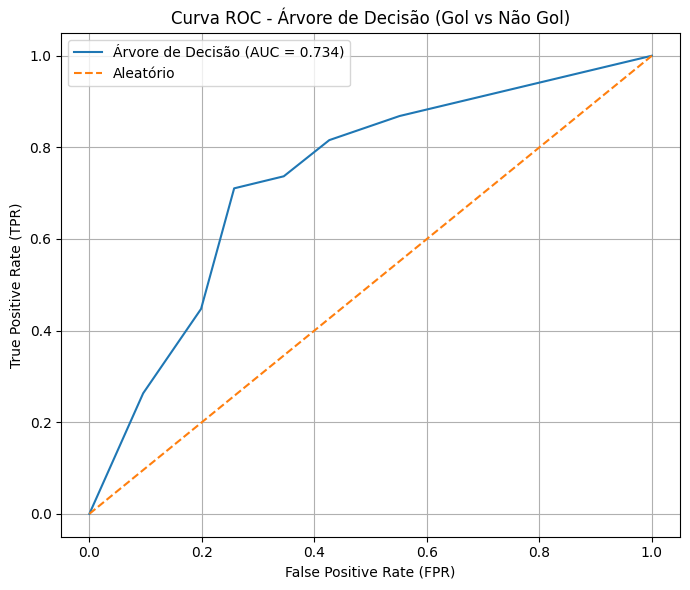

In [385]:
y_scores = dt_model_selected.predict_proba(
    X_test
)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# AUC
auc_score = roc_auc_score(y_test, y_scores)


plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Árvore de Decisão (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Aleatório')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Árvore de Decisão (Gol vs Não Gol)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [386]:
def round_to_interpretable(value, sig_figs=2):
    """
    Arredonda valor para ser interpretável com no máximo 2 algarismos significativos.
    Exemplos:
    - 3798.158 → 3800
    - 842.838 → 840
    - 15.234 → 15
    - 0.523 → 0.52
    """
    if value == 0:
        return 0

    # Determina a ordem de magnitude
    magnitude = 10 ** (np.floor(np.log10(abs(value))))

    # Para valores >= 10, arredonda para múltiplos redondos
    if abs(value) >= 10:
        # Arredonda para a potência de 10 mais próxima (10, 100, 1000, etc.)
        if abs(value) >= 1000:
            return round(value, -2)  # arredonda para centenas
        elif abs(value) >= 100:
            return round(value, -1)  # arredonda para dezenas
        else:
            return round(value, 0)   # arredonda para inteiros
    else:
        # Para valores < 10, mantém 2 casas decimais
        return round(value, 2)


def compute_rule_metrics(rule_conditions, X, y, positive_class=1):
    """
    Calcula Cobertura, Confiança e Lift para uma regra.
    - rule_conditions: lista de tuplas (feature, op, threshold)
    - X: DataFrame de treino
    - y: Series com rótulos
    """
    mask = np.ones(len(X), dtype=bool)

    for feature, op, threshold in rule_conditions:
        if op == "<=":
            mask &= (X[feature] <= threshold)
        else:
            mask &= (X[feature] > threshold)

    # Instâncias cobertas pela regra
    covered_y = y[mask]

    if len(covered_y) == 0:
        return 0, 0, 0  # Evita divisão por zero

    # Métricas
    coverage = len(covered_y) / len(y)
    confidence = covered_y.mean()  # probabilidade de gol dentro da regra
    base_rate = y.mean()  # probabilidade geral de gol
    lift = confidence / base_rate if base_rate > 0 else 0

    return coverage, confidence, lift


def extract_rules_with_metrics(tree_model, X, y, class_names=['Não Gol','Gol']):
    """
    Extrai caminhos até folhas com classe 'Gol'
    e calcula cobertura, confiança e lift.
    """
    tree_ = tree_model.tree_
    feature_names = X.columns.tolist()

    def recurse(node, path):
        paths = []

        # Nó folha
        if tree_.children_left[node] == tree_.children_right[node]:
            values = tree_.value[node][0]
            predicted_class = np.argmax(values)

            if predicted_class == 1:  # classe 'Gol'
                paths.append(path)

        else:
            feat = feature_names[tree_.feature[node]]
            thr = tree_.threshold[node]

            # Esquerda
            paths += recurse(
                tree_.children_left[node],
                path + [(feat, "<=", thr)]
            )
            # Direita
            paths += recurse(
                tree_.children_right[node],
                path + [(feat, ">", thr)]
            )

        return paths

    gol_paths = recurse(0, [])

    # Processar métricas
    rules_output = []
    for i, path in enumerate(gol_paths, 1):
        coverage, confidence, lift = compute_rule_metrics(path, X, y)

        rules_output.append({
            "id": i,
            "path": path,
            "coverage": coverage,
            "confidence": confidence,
            "lift": lift
        })

    return rules_output


rules = extract_rules_with_metrics(dt_model_selected, X_train, y_train)

print("REGRAS PARA 'GOL' COM COBERTURA, CONFIANÇA E LIFT")
print("(Thresholds arredondados para interpretabilidade)\n")

for r in rules:
    print(f"\nRegra {r['id']}:")
    for feat, op, thr in r["path"]:
        thr_rounded = round_to_interpretable(thr)
        print(f"  - {feat} {op} {thr_rounded}")
    print(f"  → Cobertura: {r['coverage']*100:.2f}%")
    print(f"  → Confiança: {r['confidence']*100:.2f}%")
    print(f"  → Lift: {r['lift']:.3f}")
    print("-" * 50)

REGRAS PARA 'GOL' COM COBERTURA, CONFIANÇA E LIFT
(Thresholds arredondados para interpretabilidade)


Regra 1:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal <= 3000.0
  - ball_acceleration_norm <= 64400.0
  → Cobertura: 14.08%
  → Confiança: 61.22%
  → Lift: 2.822
--------------------------------------------------

Regra 2:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal <= 3000.0
  - ball_acceleration_norm > 64400.0
  → Cobertura: 10.78%
  → Confiança: 41.33%
  → Lift: 1.905
--------------------------------------------------

Regra 3:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal > 3000.0
  - feat_visible_angle > 22.0
  → Cobertura: 15.80%
  → Confiança: 35.45%
  → Lift: 1.634
--------------------------------------------------


# Original

## Regressão Logística

### Treinando modelo

Fitting 5 folds for each of 64 candidates, totalling 320 fits
MELHOR SCORE (CV): 0.8286573937062247
MELHORES PARÂMETROS:
  clf__C: 0.01
  clf__class_weight: balanced
  selector: RFE(estimator=LogisticRegression(max_iter=1000, random_state=42))
  selector__n_features_to_select: 5

MELHOR THRESHOLD: 0.550
F1-SCORE (CV) com este threshold: 0.5589

AVALIAÇÃO FINAL NO CONJUNTO DE TESTE

MATRIZ DE CONFUSÃO:


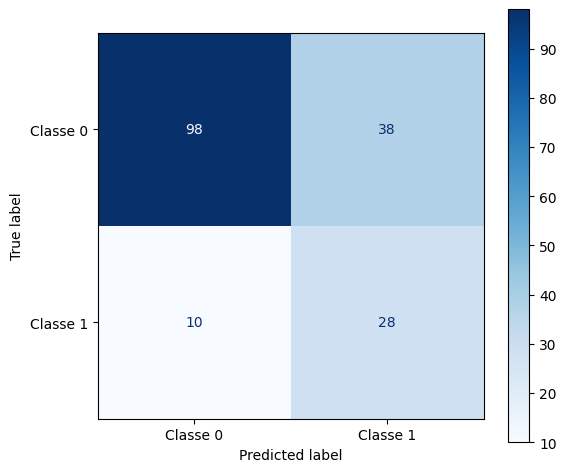


RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       136
           1       0.42      0.74      0.54        38

    accuracy                           0.72       174
   macro avg       0.67      0.73      0.67       174
weighted avg       0.80      0.72      0.75       174


ROC-AUC: 0.7558


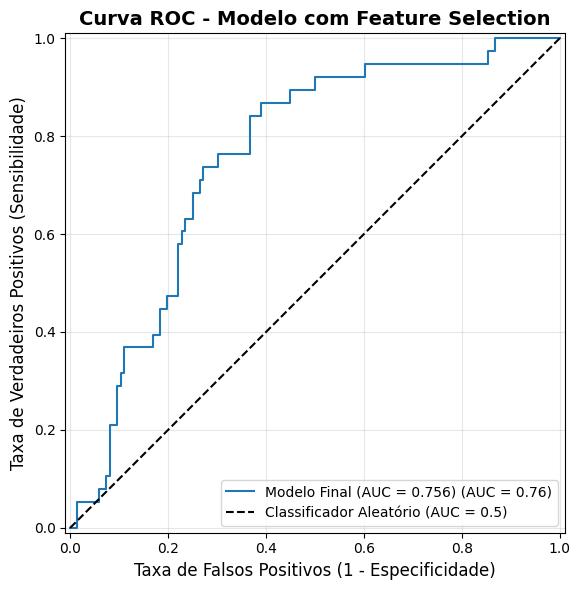


FEATURES PARA O MODELO DE PRODUÇÃO (5):
 1. ball_velocity_norm
 2. ball_acceleration_norm
 3. kicker_velocity_norm
 4. feat_dist_goal
 5. feat_angle_goal


In [387]:
# 1. SEPARAÇÃO INICIAL
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. PIPELINE COM SELEÇÃO DE FEATURES
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif)),  # ou RFE
    ('clf', LogisticRegression(
        random_state=42,
        max_iter=5000,
        solver='liblinear'
    ))
])

# 3. GRADE DE HIPERPARÂMETROS EXPANDIDA
param_grid = [
    {
        'selector': [SelectKBest(score_func=f_classif)],
        'selector__k': [5, 10, 15, 'all'],  # número de features
        'clf__C': [0.001, 0.01, 0.1, 1, 10],
        'clf__class_weight': [None, 'balanced']
    },
    {
        'selector': [RFE(LogisticRegression(random_state=42, max_iter=1000))],
        'selector__n_features_to_select': [5, 10, 15],
        'clf__C': [0.001, 0.01, 0.1, 1],
        'clf__class_weight': [None, 'balanced']
    }
]

# 4. GRID SEARCH COM VALIDAÇÃO CRUZADA
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True  # IMPORTANTE: re-treina com todos os dados
)

grid.fit(X_train, y_train)

# 5. MELHORES PARÂMETROS E FEATURES
print("=" * 60)
print("MELHOR SCORE (CV):", grid.best_score_)
print("MELHORES PARÂMETROS:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

# 6. IDENTIFICAR AS FEATURES SELECIONADAS
best_pipeline = grid.best_estimator_
selected_features = X_train.columns

# 7. TUNING DE THRESHOLD NO CONJUNTO DE TREINO (com validação cruzada)
def find_best_threshold(model, X, y, cv_splits=5):
    """Encontra o melhor threshold usando validação cruzada"""

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        # Re-treinar no fold de treino
        model.fit(X_train_cv, y_train_cv)
        y_probs = model.predict_proba(X_val_cv)[:, 1]

        # Avaliar cada threshold
        fold_scores = []
        for th in thresholds:
            y_pred = (y_probs >= th).astype(int)
            # ✅ CORREÇÃO: Usar F1-score para predições binárias
            score = f1_score(y_val_cv, y_pred, zero_division=0)
            fold_scores.append(score)

        best_scores.append(fold_scores)

    # Média entre folds
    mean_scores = np.mean(best_scores, axis=0)
    best_idx = np.argmax(mean_scores)
    best_threshold = thresholds[best_idx]

    return best_threshold, mean_scores[best_idx]

# Encontrar melhor threshold
threshold_vencedor, threshold_score = find_best_threshold(
    best_pipeline, X_train, y_train, cv_splits=5
)
print(f"\nMELHOR THRESHOLD: {threshold_vencedor:.3f}")
print(f"F1-SCORE (CV) com este threshold: {threshold_score:.4f}")

# 8. MODELO FINAL (treinado com TODOS os dados de treino)
# O grid.best_estimator_ já está treinado com refit=True
modelo_final = grid.best_estimator_

# 9. PREDIÇÕES NO TESTE
y_probs_test = modelo_final.predict_proba(X_test)[:, 1]
predicoes_finais = (y_probs_test >= threshold_vencedor).astype(int)

# 10. AVALIAÇÃO FINAL
print("\n" + "=" * 60)
print("AVALIAÇÃO FINAL NO CONJUNTO DE TESTE")
print("=" * 60)

print("\nMATRIZ DE CONFUSÃO:")
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicoes_finais,
    display_labels=['Classe 0', 'Classe 1'],
    cmap='Blues',
    ax=ax,
    values_format='d'
)

plt.tight_layout()
plt.show()

print("\nRELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, predicoes_finais))

auc_test = roc_auc_score(y_test, y_probs_test)  # CORRIGIDO: definir auc_test
print(f"\nROC-AUC: {auc_test:.4f}")

# 11. VISUALIZAÇÕES - APENAS CURVA ROC
fig, ax = plt.subplots(figsize=(8, 6))

# Curva ROC
RocCurveDisplay.from_estimator(
    modelo_final,
    X_test,
    y_test,
    ax=ax,
    name=f'Modelo Final (AUC = {auc_test:.3f})'
)

# Linha de referência (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório (AUC = 0.5)')

# Detalhes do gráfico
ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
ax.set_title('Curva ROC - Modelo com Feature Selection', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.show()

# 12. SALVAR AS FEATURES IMPORTANTES
if 'selector' in best_pipeline.named_steps:
    selector = best_pipeline.named_steps['selector']
    if hasattr(selector, 'get_support'):
        selected_features = X.columns[selector.get_support()]
        print(f"\nFEATURES PARA O MODELO DE PRODUÇÃO ({len(selected_features)}):")
        for i, feat in enumerate(selected_features, 1):
            print(f"{i:2d}. {feat}")

## Árvore de Decisão

In [388]:
# Calcular estatísticas dos dados
n_samples = len(y_train)
n_gol = sum(y_train)
n_nao_gol = n_samples - n_gol
balance_ratio = n_nao_gol / n_gol if n_gol > 0 else 1

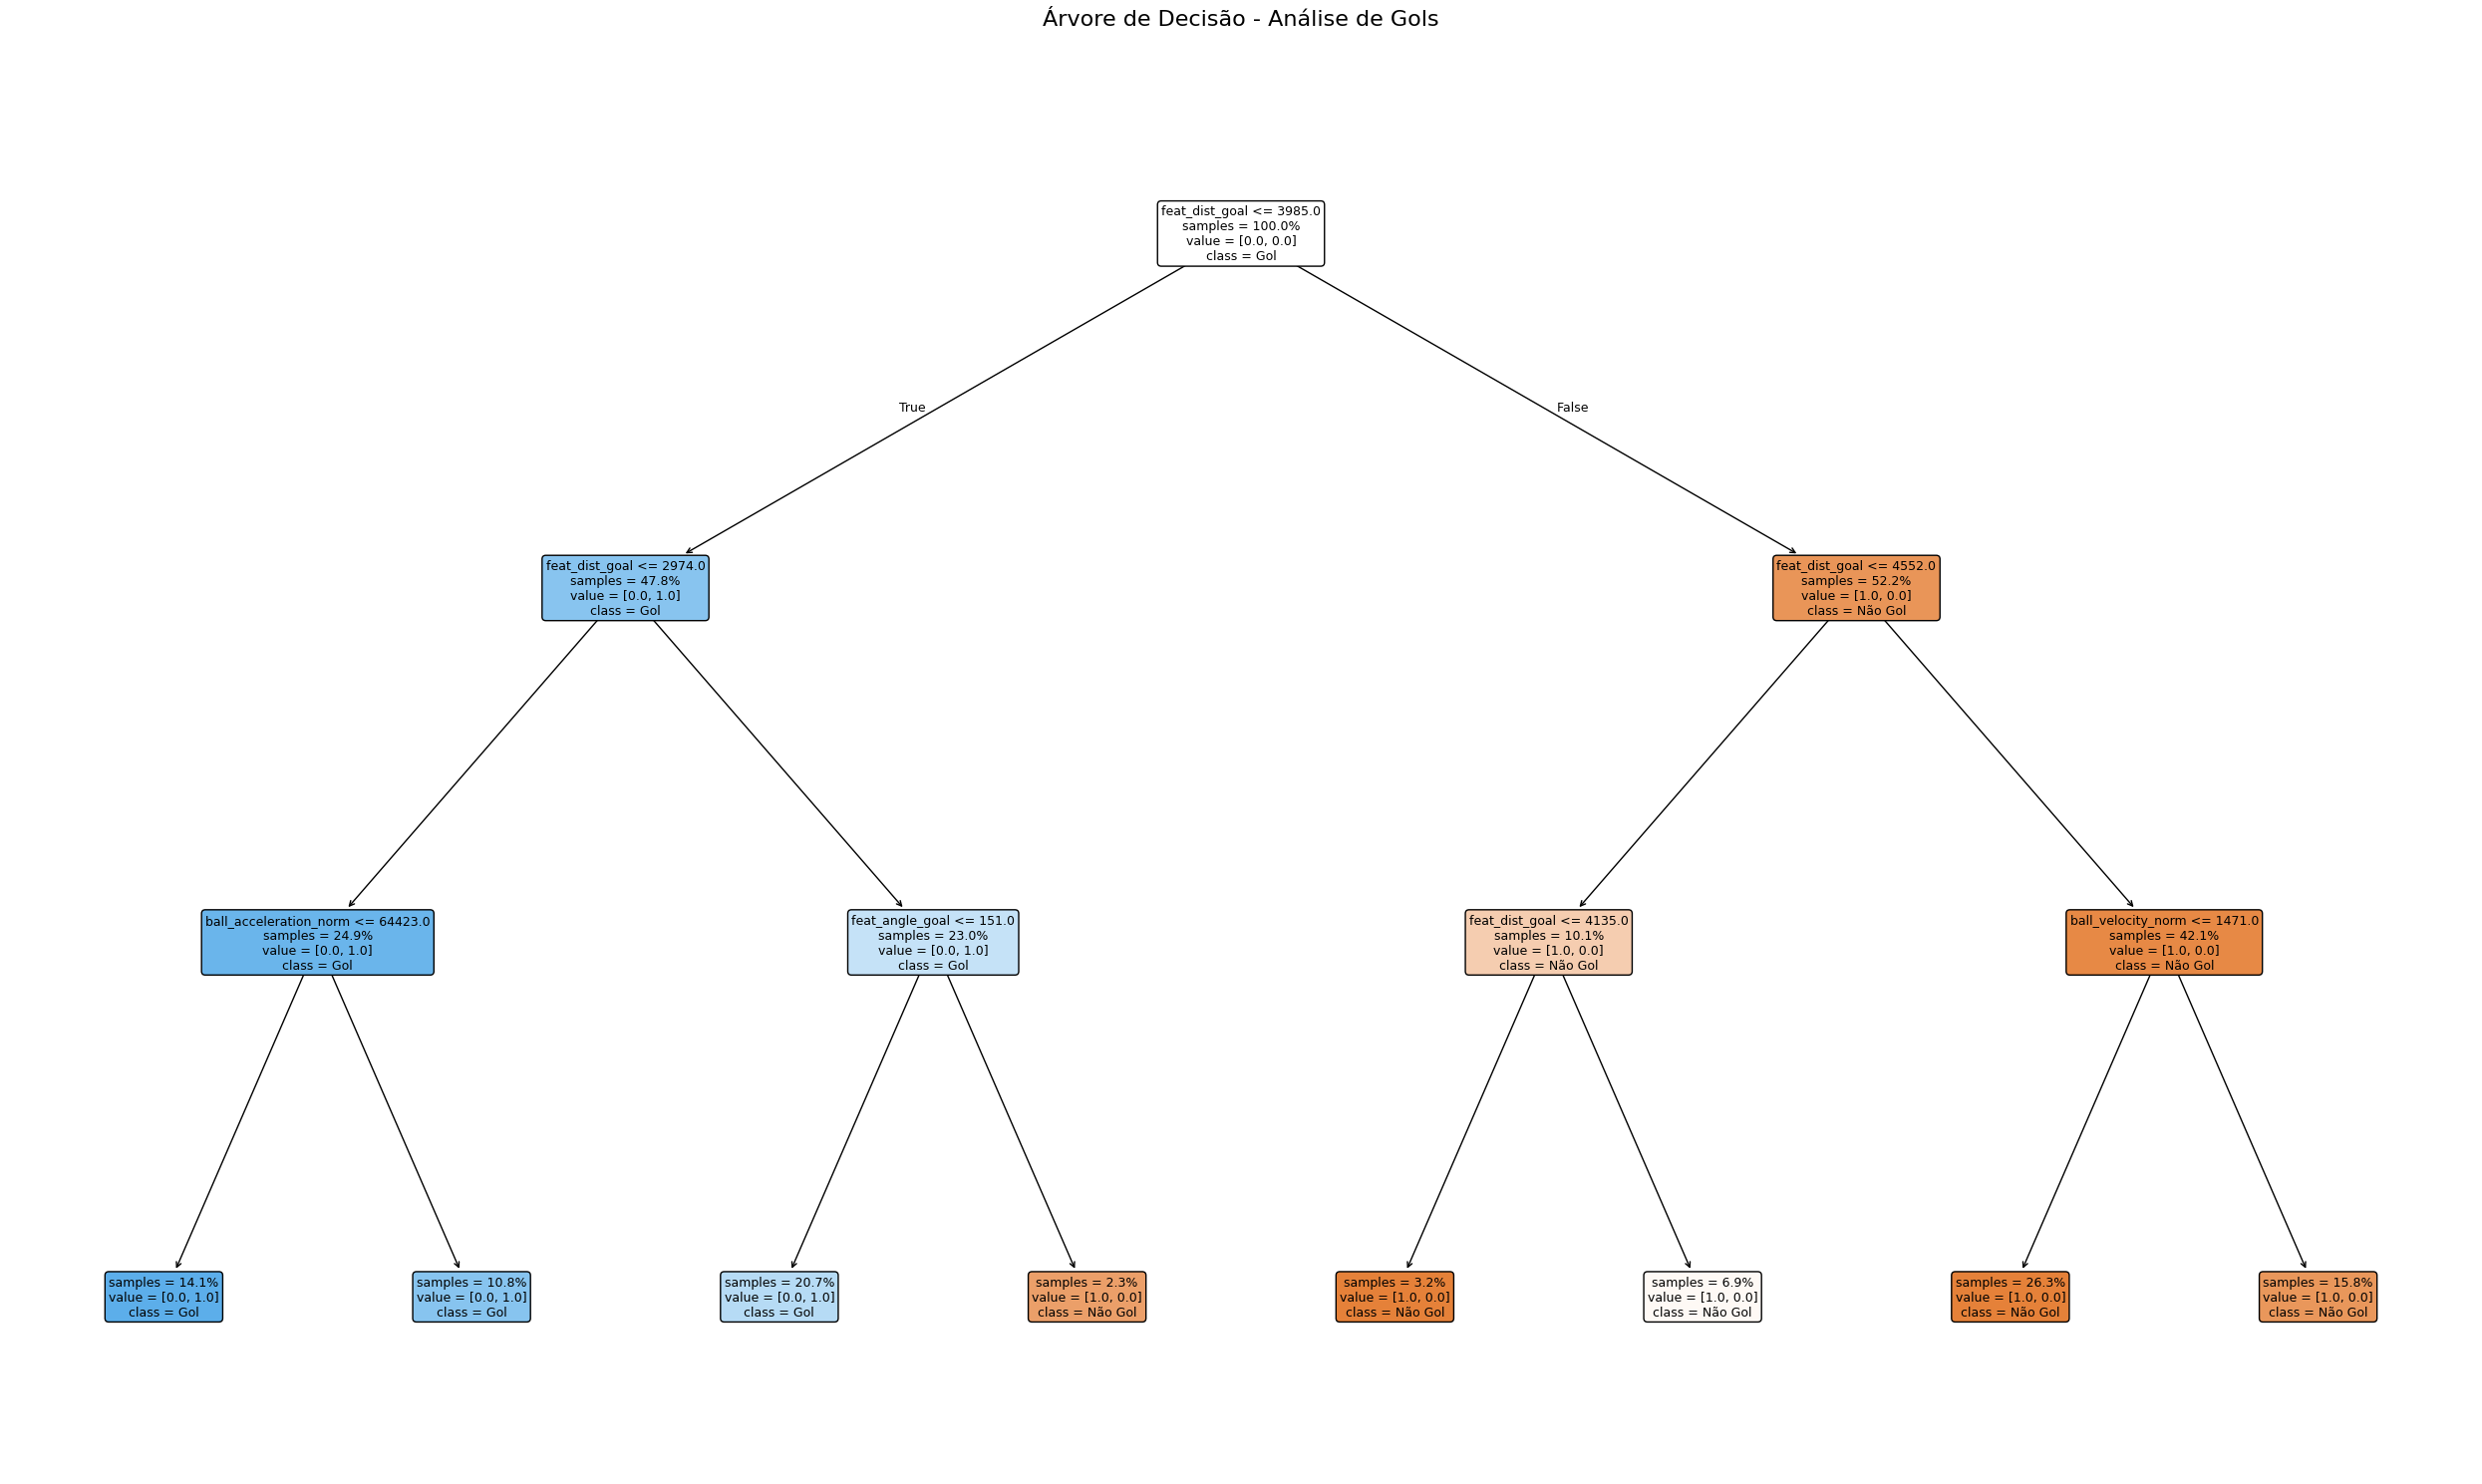

In [389]:
# Treinar a árvore
dt_model_selected = DecisionTreeClassifier(
    max_depth=3,
    criterion = 'gini',
    min_samples_leaf= 14,
    class_weight='balanced',
    random_state=42,

)

dt_model_selected.fit(X_train[selected_features], y_train)

# Plotar a árvore
plt.figure(figsize=(25, 15))

plot_tree(dt_model_selected,
          feature_names=selected_features,
          class_names=['Não Gol', 'Gol'],
          filled=True,
          rounded=True,
          fontsize=9,
          impurity=False,
          proportion=True,
          precision=0)

plt.title("Árvore de Decisão - Análise de Gols\n", fontsize=16)
plt.tight_layout()
plt.show()


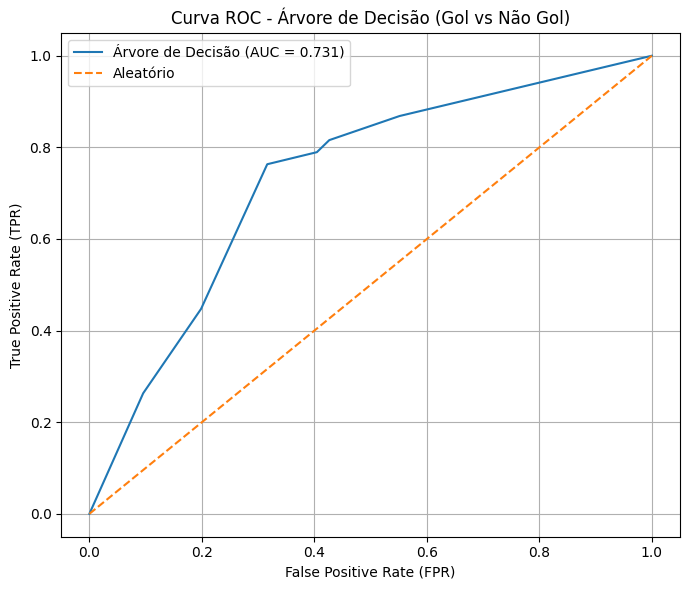

In [390]:
y_scores = dt_model_selected.predict_proba(
    X_test[selected_features]
)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# AUC
auc_score = roc_auc_score(y_test, y_scores)


plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Árvore de Decisão (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Aleatório')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Árvore de Decisão (Gol vs Não Gol)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [391]:
rules = extract_rules_with_metrics(dt_model_selected, X_train[selected_features], y_train)

print("REGRAS PARA 'GOL' COM COBERTURA, CONFIANÇA E LIFT")
print("(Thresholds arredondados para interpretabilidade)\n")

for r in rules:
    print(f"\nRegra {r['id']}:")
    for feat, op, thr in r["path"]:
        thr_rounded = round_to_interpretable(thr)
        print(f"  - {feat} {op} {thr_rounded}")
    print(f"  → Cobertura: {r['coverage']*100:.2f}%")
    print(f"  → Confiança: {r['confidence']*100:.2f}%")
    print(f"  → Lift: {r['lift']:.3f}")
    print("-" * 50)

REGRAS PARA 'GOL' COM COBERTURA, CONFIANÇA E LIFT
(Thresholds arredondados para interpretabilidade)


Regra 1:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal <= 3000.0
  - ball_acceleration_norm <= 64400.0
  → Cobertura: 14.08%
  → Confiança: 61.22%
  → Lift: 2.822
--------------------------------------------------

Regra 2:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal <= 3000.0
  - ball_acceleration_norm > 64400.0
  → Cobertura: 10.78%
  → Confiança: 41.33%
  → Lift: 1.905
--------------------------------------------------

Regra 3:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal > 3000.0
  - feat_angle_goal <= 150.0
  → Cobertura: 20.69%
  → Confiança: 30.56%
  → Lift: 1.408
--------------------------------------------------


---

# No-corr Features


## Regressão Logística

In [393]:
X = df_reduced.drop('goal', axis=1)
y = df_reduced['goal']

## Treinando modelo

Fitting 5 folds for each of 64 candidates, totalling 320 fits
MELHOR SCORE (CV): 0.8287955016277004
MELHORES PARÂMETROS:
  clf__C: 10
  clf__class_weight: balanced
  selector: SelectKBest()
  selector__k: 5

FEATURES SELECIONADAS (5):
['kicker_velocity_norm', 'goalkeeper_velocity_norm', 'feat_dist_goal', 'feat_angle_goal', 'feat_opponents_in_cone']

TOP 10 FEATURES:
                         Feature       Score
3                 feat_dist_goal  145.860351
7         feat_opponents_in_cone   42.106975
2       goalkeeper_velocity_norm   22.254061
1           kicker_velocity_norm    3.414749
4                feat_angle_goal    0.867478
9  feat_orientation_to_goal_diff    0.824165
6         feat_min_dist_opponent    0.816431
0             ball_velocity_norm    0.481441
8         feat_robot_orientation    0.367235
5             feat_visible_angle    0.249162

MELHOR THRESHOLD: 0.550
F1-SCORE (CV) com este threshold: 0.5808

AVALIAÇÃO FINAL NO CONJUNTO DE TESTE

MATRIZ DE CONFUSÃO:


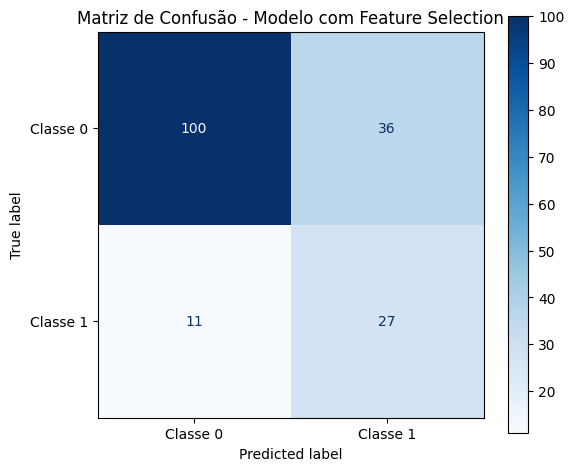


RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81       136
           1       0.43      0.71      0.53        38

    accuracy                           0.73       174
   macro avg       0.66      0.72      0.67       174
weighted avg       0.80      0.73      0.75       174


ROC-AUC: 0.7421


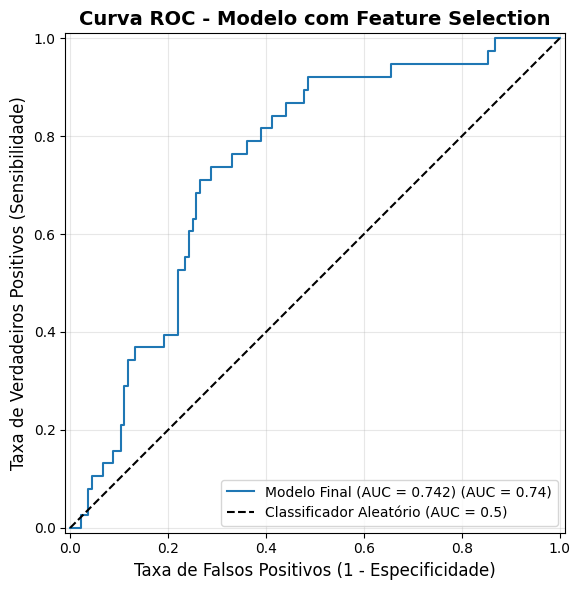


FEATURES PARA O MODELO DE PRODUÇÃO (5):
 1. goalkeeper_velocity_norm
 2. feat_dist_goal
 3. feat_angle_goal
 4. feat_opponents_in_cone
 5. feat_orientation_to_goal_diff


In [394]:
# 1. SEPARAÇÃO INICIAL
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. PIPELINE COM SELEÇÃO DE FEATURES
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif)),  # ou RFE
    ('clf', LogisticRegression(
        random_state=42,
        max_iter=5000,
        solver='liblinear'
    ))
])

# 3. GRADE DE HIPERPARÂMETROS EXPANDIDA
param_grid = [
    {
        'selector': [SelectKBest(score_func=f_classif)],
        'selector__k': [5, 10, 15, 'all'],  # número de features
        'clf__C': [0.001, 0.01, 0.1, 1, 10],
        'clf__class_weight': [None, 'balanced']
    },
    {
        'selector': [RFE(LogisticRegression(random_state=42, max_iter=1000))],
        'selector__n_features_to_select': [5, 10, 15],
        'clf__C': [0.001, 0.01, 0.1, 1],
        'clf__class_weight': [None, 'balanced']
    }
]

# 4. GRID SEARCH COM VALIDAÇÃO CRUZADA
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True  # IMPORTANTE: re-treina com todos os dados
)

grid.fit(X_train, y_train)

# 5. MELHORES PARÂMETROS E FEATURES
print("=" * 60)
print("MELHOR SCORE (CV):", grid.best_score_)
print("MELHORES PARÂMETROS:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

# 6. IDENTIFICAR AS FEATURES SELECIONADAS
best_pipeline = grid.best_estimator_
if 'selector' in best_pipeline.named_steps:
    selector = best_pipeline.named_steps['selector']
    if hasattr(selector, 'get_support'):
        selected_features = X.columns[selector.get_support()]
        print(f"\nFEATURES SELECIONADAS ({len(selected_features)}):")
        print(selected_features.tolist())

        # Importância das features
        if hasattr(selector, 'scores_'):
            feature_scores = pd.DataFrame({
                'Feature': X.columns,
                'Score': selector.scores_,
                'P-value': selector.pvalues_
            })
            print("\nTOP 10 FEATURES:")
            print(feature_scores.nlargest(10, 'Score')[['Feature', 'Score']])

# 7. TUNING DE THRESHOLD NO CONJUNTO DE TREINO (com validação cruzada)
def find_best_threshold(model, X, y, cv_splits=5):
    """Encontra o melhor threshold usando validação cruzada"""

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        # Re-treinar no fold de treino
        model.fit(X_train_cv, y_train_cv)
        y_probs = model.predict_proba(X_val_cv)[:, 1]

        # Avaliar cada threshold
        fold_scores = []
        for th in thresholds:
            y_pred = (y_probs >= th).astype(int)
            # ✅ CORREÇÃO: Usar F1-score para predições binárias
            score = f1_score(y_val_cv, y_pred, zero_division=0)
            fold_scores.append(score)

        best_scores.append(fold_scores)

    # Média entre folds
    mean_scores = np.mean(best_scores, axis=0)
    best_idx = np.argmax(mean_scores)
    best_threshold = thresholds[best_idx]

    return best_threshold, mean_scores[best_idx]

# Encontrar melhor threshold
threshold_vencedor, threshold_score = find_best_threshold(
    best_pipeline, X_train, y_train, cv_splits=5
)
print(f"\nMELHOR THRESHOLD: {threshold_vencedor:.3f}")
print(f"F1-SCORE (CV) com este threshold: {threshold_score:.4f}")

# 8. MODELO FINAL (treinado com TODOS os dados de treino)
# O grid.best_estimator_ já está treinado com refit=True
modelo_final = grid.best_estimator_

# 9. PREDIÇÕES NO TESTE
y_probs_test = modelo_final.predict_proba(X_test)[:, 1]
predicoes_finais = (y_probs_test >= threshold_vencedor).astype(int)

# 10. AVALIAÇÃO FINAL
print("\n" + "=" * 60)
print("AVALIAÇÃO FINAL NO CONJUNTO DE TESTE")
print("=" * 60)

print("\nMATRIZ DE CONFUSÃO:")
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicoes_finais,
    display_labels=['Classe 0', 'Classe 1'],
    cmap='Blues',
    ax=ax,
    values_format='d'
)

ax.set_title('Matriz de Confusão - Modelo com Feature Selection', fontsize=12)
plt.tight_layout()
plt.show()

print("\nRELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, predicoes_finais))

auc_test = roc_auc_score(y_test, y_probs_test)  # CORRIGIDO: definir auc_test
print(f"\nROC-AUC: {auc_test:.4f}")

# 11. VISUALIZAÇÕES - APENAS CURVA ROC
fig, ax = plt.subplots(figsize=(8, 6))

# Curva ROC
RocCurveDisplay.from_estimator(
    modelo_final,
    X_test,
    y_test,
    ax=ax,
    name=f'Modelo Final (AUC = {auc_test:.3f})'
)

# Linha de referência (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório (AUC = 0.5)')

# Detalhes do gráfico
ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
ax.set_title('Curva ROC - Modelo com Feature Selection', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.show()

# 12. SALVAR AS FEATURES IMPORTANTES
if 'selector' in best_pipeline.named_steps:
    selector = best_pipeline.named_steps['selector']
    if hasattr(selector, 'get_support'):
        selected_features = X.columns[selector.get_support()]
        print(f"\nFEATURES PARA O MODELO DE PRODUÇÃO ({len(selected_features)}):")
        for i, feat in enumerate(selected_features, 1):
            print(f"{i:2d}. {feat}")

## Árvore de Decisão

In [395]:
# Calcular estatísticas dos dados
n_samples = len(y_train)
n_gol = sum(y_train)
n_nao_gol = n_samples - n_gol
balance_ratio = n_nao_gol / n_gol if n_gol > 0 else 1

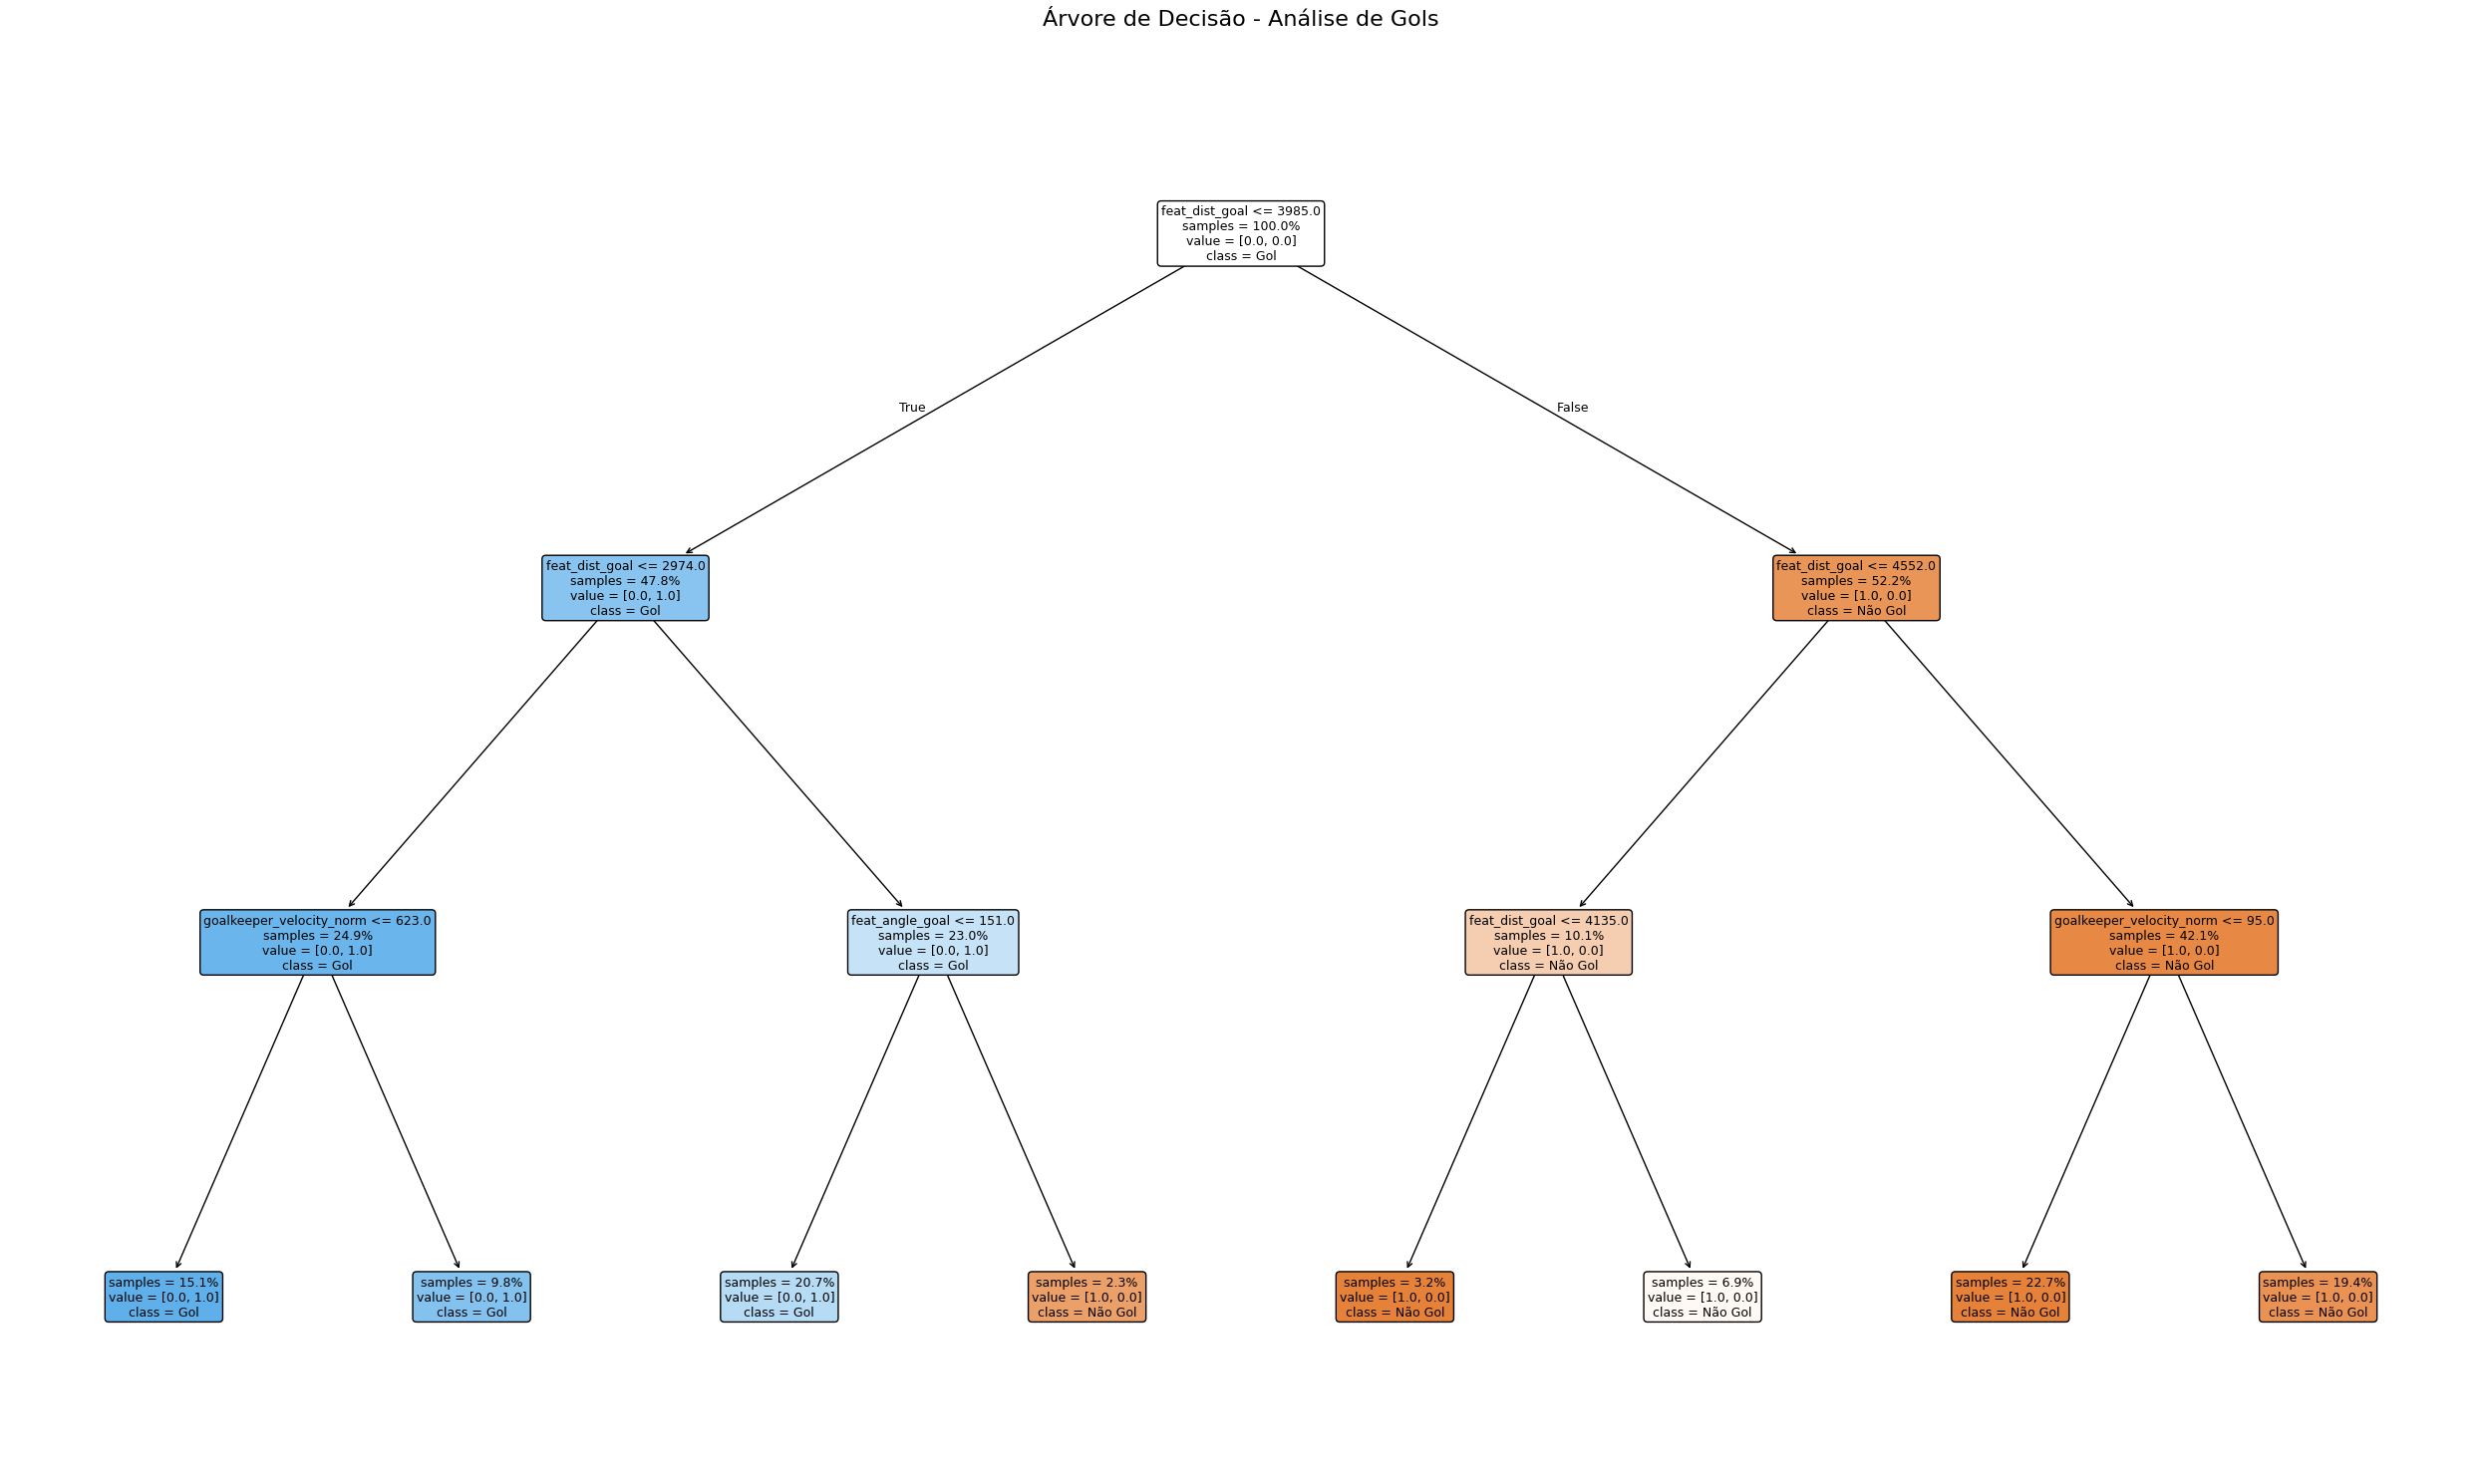

In [396]:
# Treinar a árvore
dt_model_selected = DecisionTreeClassifier(
    max_depth=3,
    criterion = 'gini',
    min_samples_leaf= 14,
    class_weight='balanced',
    random_state=42,

)

dt_model_selected.fit(X_train[selected_features], y_train)

# Plotar a árvore
plt.figure(figsize=(25, 15))

plot_tree(dt_model_selected,
          feature_names=selected_features,
          class_names=['Não Gol', 'Gol'],
          filled=True,
          rounded=True,
          fontsize=9,
          impurity=False,
          proportion=True,
          precision=0)

plt.title("Árvore de Decisão - Análise de Gols\n", fontsize=16)
plt.tight_layout()
plt.show()


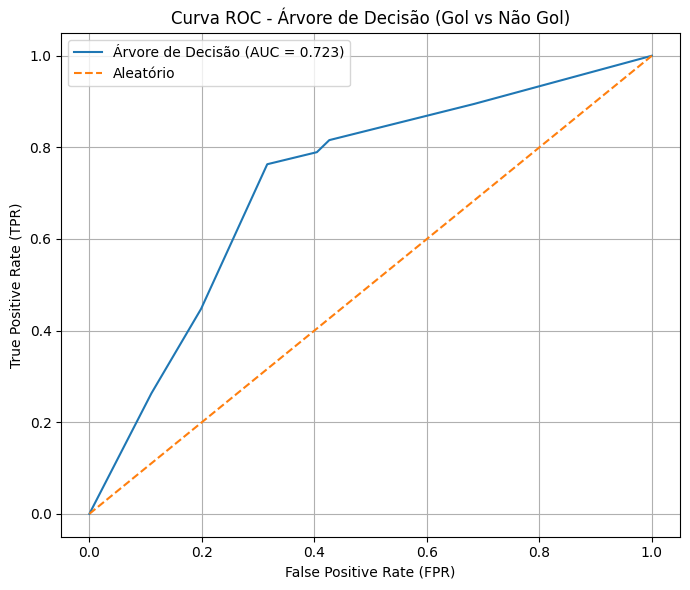

In [397]:
y_scores = dt_model_selected.predict_proba(
    X_test[selected_features]
)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# AUC
auc_score = roc_auc_score(y_test, y_scores)


plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Árvore de Decisão (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Aleatório')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Árvore de Decisão (Gol vs Não Gol)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [398]:
rules = extract_rules_with_metrics(dt_model_selected, X_train[selected_features], y_train)

print("REGRAS PARA 'GOL' COM COBERTURA, CONFIANÇA E LIFT")
print("(Thresholds arredondados para interpretabilidade)\n")

for r in rules:
    print(f"\nRegra {r['id']}:")
    for feat, op, thr in r["path"]:
        thr_rounded = round_to_interpretable(thr)
        print(f"  - {feat} {op} {thr_rounded}")
    print(f"  → Cobertura: {r['coverage']*100:.2f}%")
    print(f"  → Confiança: {r['confidence']*100:.2f}%")
    print(f"  → Lift: {r['lift']:.3f}")
    print("-" * 50)

REGRAS PARA 'GOL' COM COBERTURA, CONFIANÇA E LIFT
(Thresholds arredondados para interpretabilidade)


Regra 1:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal <= 3000.0
  - goalkeeper_velocity_norm <= 620.0
  → Cobertura: 15.09%
  → Confiança: 59.05%
  → Lift: 2.722
--------------------------------------------------

Regra 2:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal <= 3000.0
  - goalkeeper_velocity_norm > 620.0
  → Cobertura: 9.77%
  → Confiança: 42.65%
  → Lift: 1.966
--------------------------------------------------

Regra 3:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal > 3000.0
  - feat_angle_goal <= 150.0
  → Cobertura: 20.69%
  → Confiança: 30.56%
  → Lift: 1.408
--------------------------------------------------


---

# Oversampling + No-corr

## Regressão Logística

In [399]:
X = df_reduced.drop('goal', axis=1)
y = df_reduced['goal']

## Treinando modelo

In [400]:
# 1. SEPARAÇÃO INICIAL
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. PIPELINE COM SELEÇÃO DE FEATURES
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif)),  # ou RFE
    ('clf', LogisticRegression(
        random_state=42,
        max_iter=5000,
        solver='liblinear'
    ))
])

# 3. GRADE DE HIPERPARÂMETROS EXPANDIDA
param_grid = [
    {
        'selector': [SelectKBest(score_func=f_classif)],
        'selector__k': [5, 10, 15, 'all'],  # número de features
        'clf__C': [0.001, 0.01, 0.1, 1, 10],
        'clf__class_weight': [None, 'balanced']
    },
    {
        'selector': [RFE(LogisticRegression(random_state=42, max_iter=1000))],
        'selector__n_features_to_select': [5, 10, 15],
        'clf__C': [0.001, 0.01, 0.1, 1],
        'clf__class_weight': [None, 'balanced']
    }
]

# 4. GRID SEARCH COM VALIDAÇÃO CRUZADA
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True  # IMPORTANTE: re-treina com todos os dados
)

grid.fit(X_train_resampled, y_train_resampled)

# 5. MELHORES PARÂMETROS E FEATURES
print("=" * 60)
print("MELHOR SCORE (CV):", grid.best_score_)
print("MELHORES PARÂMETROS:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

# 6. IDENTIFICAR AS FEATURES SELECIONADAS
best_pipeline = grid.best_estimator_
if 'selector' in best_pipeline.named_steps:
    selector = best_pipeline.named_steps['selector']
    if hasattr(selector, 'get_support'):
        selected_features = X.columns[selector.get_support()]
        print(f"\nFEATURES SELECIONADAS ({len(selected_features)}):")
        print(selected_features.tolist())

        # Importância das features
        if hasattr(selector, 'scores_'):
            feature_scores = pd.DataFrame({
                'Feature': X.columns,
                'Score': selector.scores_,
                'P-value': selector.pvalues_
            })
            print("\nTOP 10 FEATURES:")
            print(feature_scores.nlargest(10, 'Score')[['Feature', 'Score']])

# 7. TUNING DE THRESHOLD NO CONJUNTO DE TREINO (com validação cruzada)
def find_best_threshold(model, X, y, cv_splits=5):
    """Encontra o melhor threshold usando validação cruzada"""

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        # Re-treinar no fold de treino
        model.fit(X_train_cv, y_train_cv)
        y_probs = model.predict_proba(X_val_cv)[:, 1]

        # Avaliar cada threshold
        fold_scores = []
        for th in thresholds:
            y_pred = (y_probs >= th).astype(int)
            # ✅ CORREÇÃO: Usar F1-score para predições binárias
            score = f1_score(y_val_cv, y_pred, zero_division=0)
            fold_scores.append(score)

        best_scores.append(fold_scores)

    # Média entre folds
    mean_scores = np.mean(best_scores, axis=0)
    best_idx = np.argmax(mean_scores)
    best_threshold = thresholds[best_idx]

    return best_threshold, mean_scores[best_idx]

# Encontrar melhor threshold
threshold_vencedor, threshold_score = find_best_threshold(
    best_pipeline, X_train, y_train, cv_splits=5
)
print(f"\nMELHOR THRESHOLD: {threshold_vencedor:.3f}")
print(f"F1-SCORE (CV) com este threshold: {threshold_score:.4f}")

# 8. MODELO FINAL (treinado com TODOS os dados de treino)
# O grid.best_estimator_ já está treinado com refit=True
modelo_final = grid.best_estimator_

# 9. PREDIÇÕES NO TESTE
y_probs_test = modelo_final.predict_proba(X_test)[:, 1]
predicoes_finais = (y_probs_test >= threshold_vencedor).astype(int)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
MELHOR SCORE (CV): 0.8366130797070953
MELHORES PARÂMETROS:
  clf__C: 10
  clf__class_weight: None
  selector: SelectKBest()
  selector__k: 5

FEATURES SELECIONADAS (5):
['kicker_velocity_norm', 'goalkeeper_velocity_norm', 'feat_dist_goal', 'feat_min_dist_opponent', 'feat_opponents_in_cone']

TOP 10 FEATURES:
                         Feature       Score
3                 feat_dist_goal  473.820067
7         feat_opponents_in_cone  146.963662
2       goalkeeper_velocity_norm   40.290705
1           kicker_velocity_norm   10.817416
6         feat_min_dist_opponent    3.093381
9  feat_orientation_to_goal_diff    1.954003
8         feat_robot_orientation    1.859128
0             ball_velocity_norm    1.697368
5             feat_visible_angle    0.874578
4                feat_angle_goal    0.565657

MELHOR THRESHOLD: 0.250
F1-SCORE (CV) com este threshold: 0.5701


## Árvore de Decisão

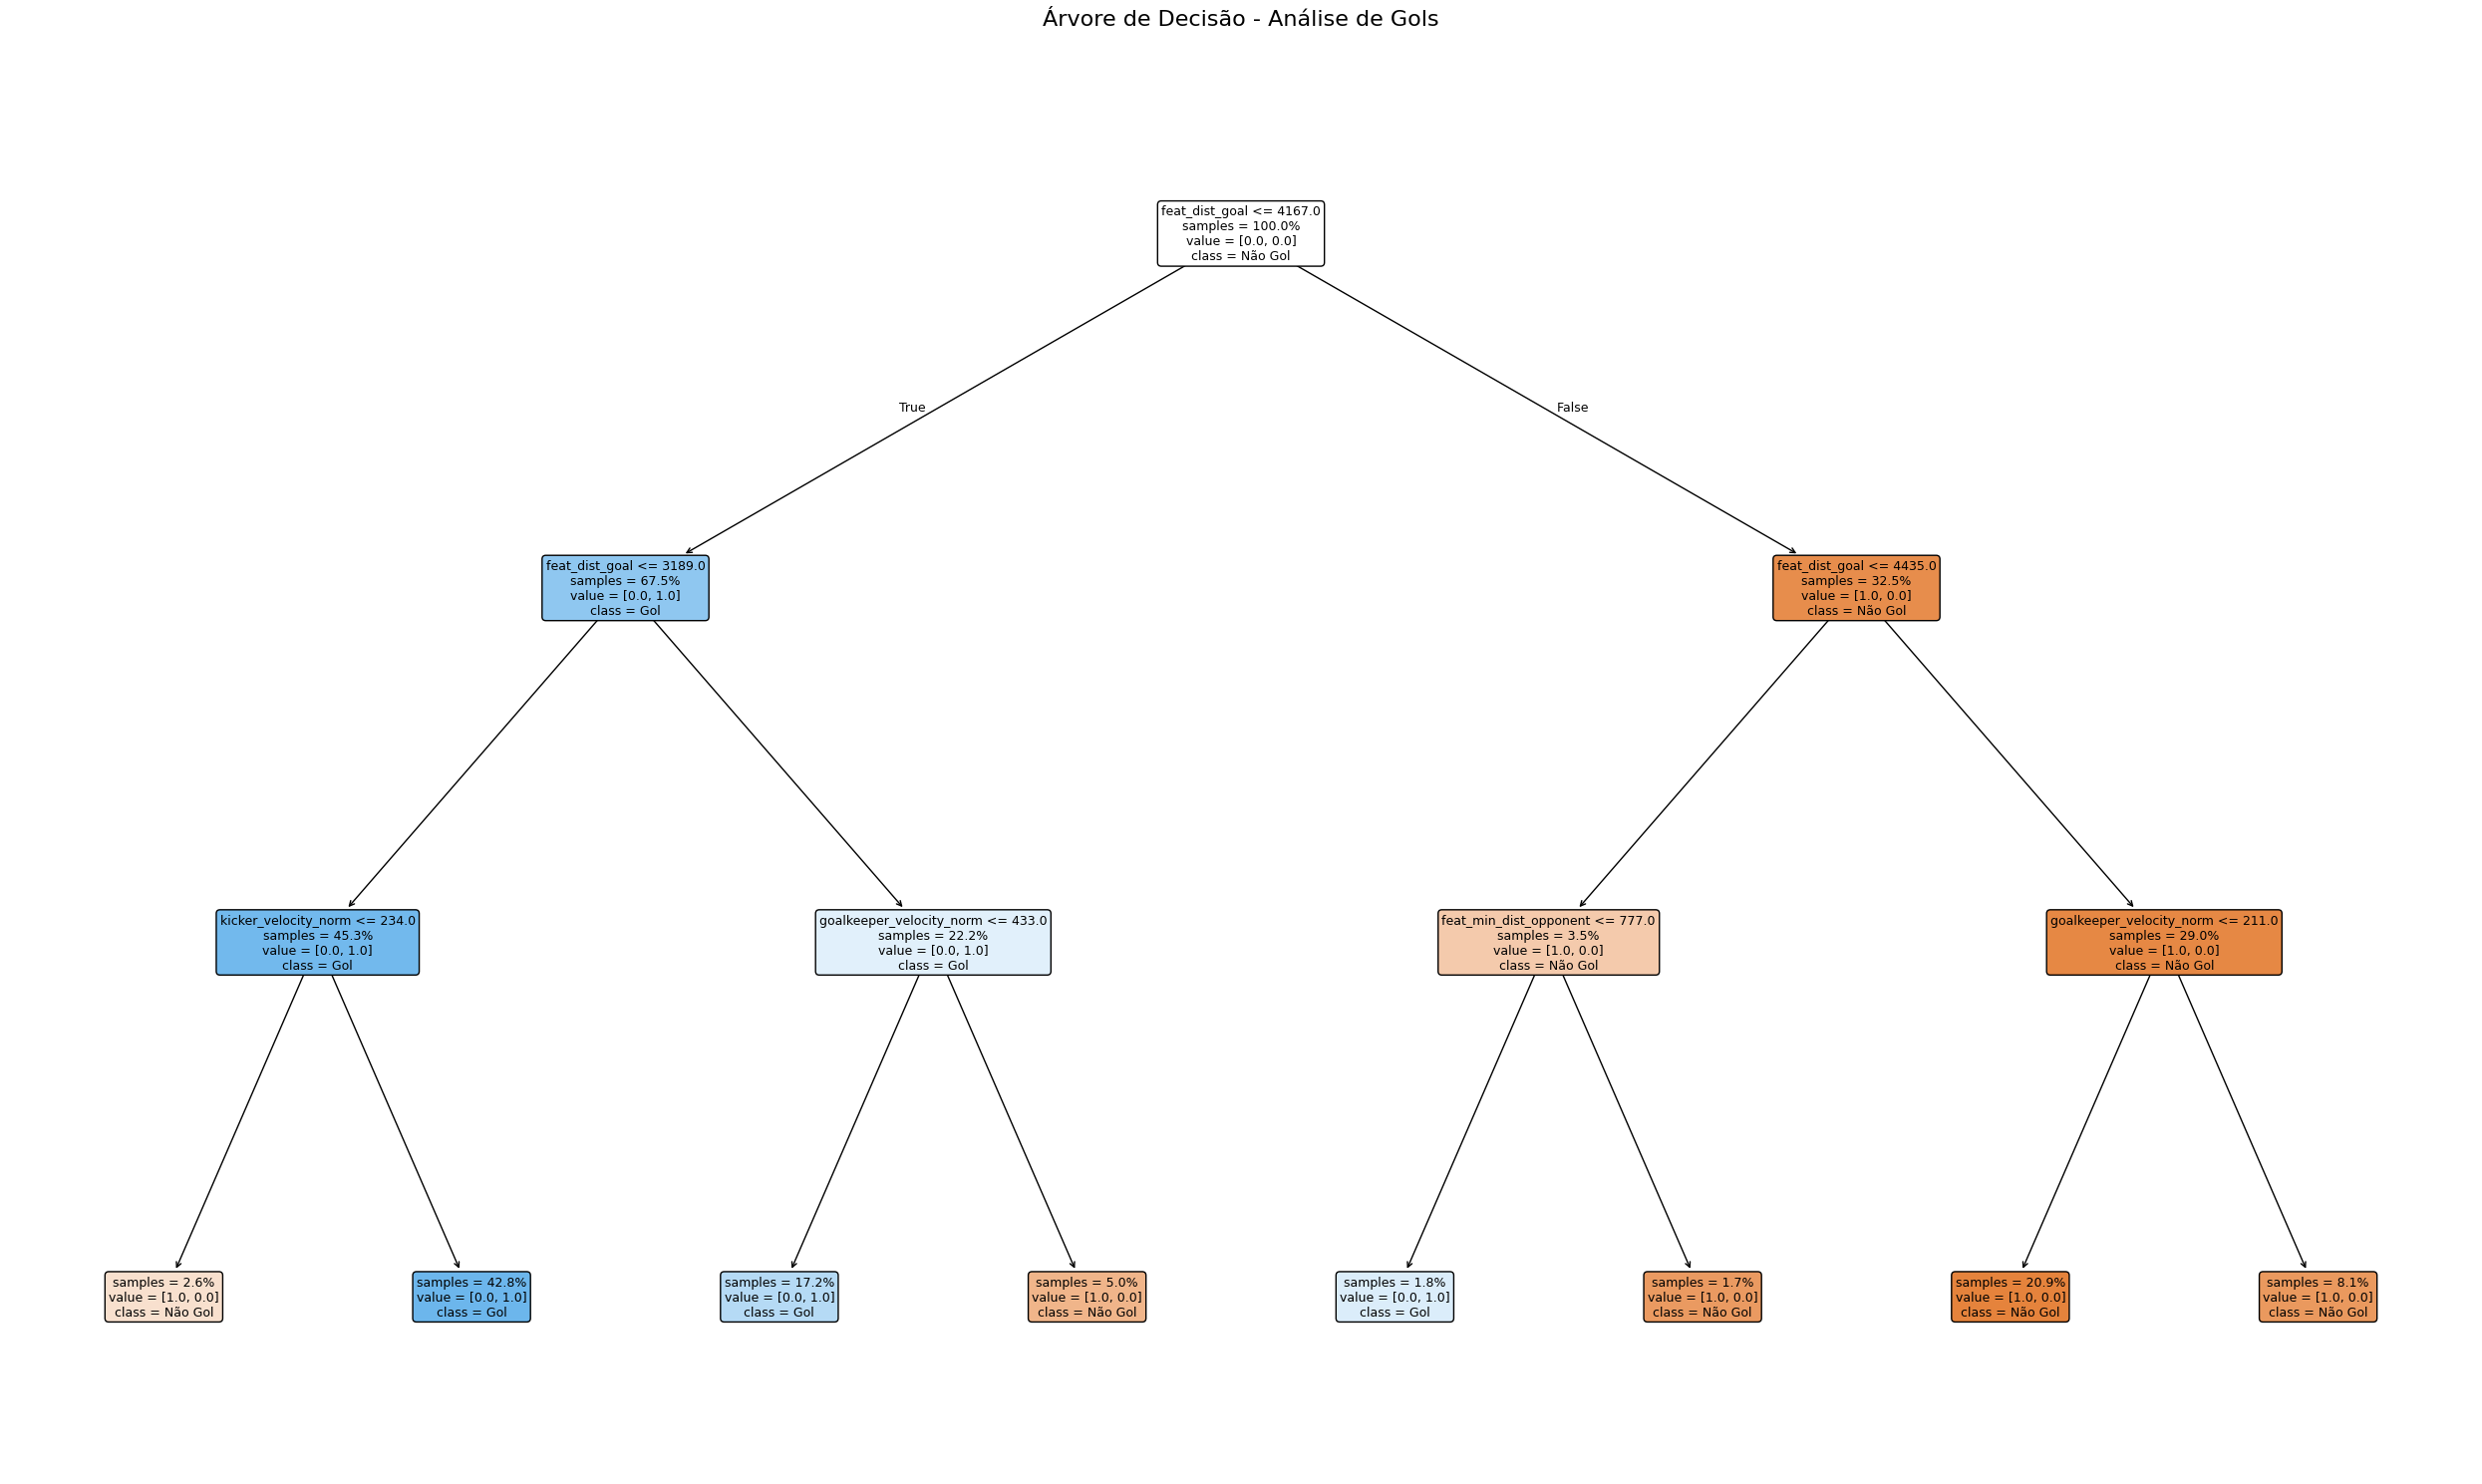

In [401]:
# Treinar a árvore
dt_model_selected = DecisionTreeClassifier(
    max_depth=3,
    criterion = 'gini',
    min_samples_leaf= 14,
    class_weight='balanced',
    random_state=42,

)

dt_model_selected.fit(X_train_resampled[selected_features], y_train_resampled)

# Plotar a árvore
plt.figure(figsize=(25, 15))

plot_tree(dt_model_selected,
          feature_names=selected_features,
          class_names=['Não Gol', 'Gol'],
          filled=True,
          rounded=True,
          fontsize=9,
          impurity=False,
          proportion=True,
          precision=0)

plt.title("Árvore de Decisão - Análise de Gols\n", fontsize=16)
plt.tight_layout()
plt.show()


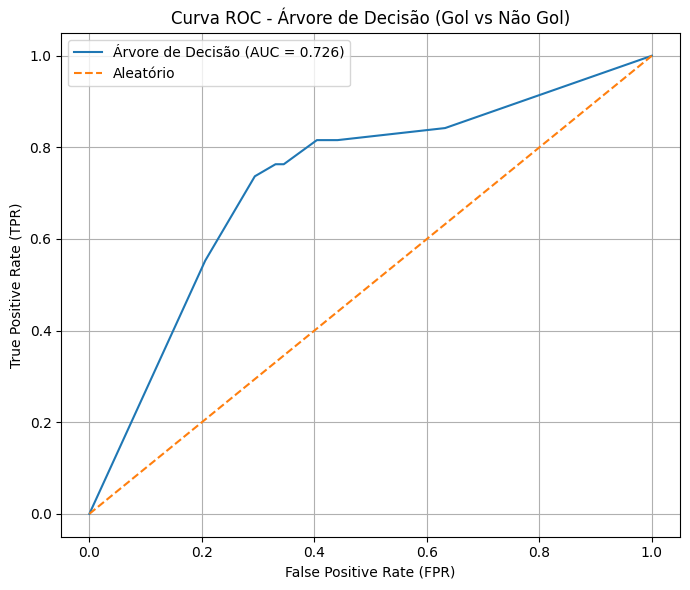

In [402]:
y_scores = dt_model_selected.predict_proba(
    X_test[selected_features]
)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# AUC
auc_score = roc_auc_score(y_test, y_scores)


plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Árvore de Decisão (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Aleatório')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Árvore de Decisão (Gol vs Não Gol)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [403]:
rules = extract_rules_with_metrics(dt_model_selected, X_train_resampled[selected_features], y_train)

print("REGRAS PARA 'GOL' COM COBERTURA, CONFIANÇA E LIFT")
print("(Thresholds arredondados para interpretabilidade)\n")

for r in rules:
    print(f"\nRegra {r['id']}:")
    for feat, op, thr in r["path"]:
        thr_rounded = round_to_interpretable(thr)
        print(f"  - {feat} {op} {thr_rounded}")
    print(f"  → Cobertura: {r['coverage']*100:.2f}%")
    print(f"  → Confiança: {r['confidence']*100:.2f}%")
    print(f"  → Lift: {r['lift']:.3f}")
    print("-" * 50)

REGRAS PARA 'GOL' COM COBERTURA, CONFIANÇA E LIFT
(Thresholds arredondados para interpretabilidade)


Regra 1:
  - feat_dist_goal <= 4200.0
  - feat_dist_goal <= 3200.0
  - kicker_velocity_norm > 230.0
  → Cobertura: 39.66%
  → Confiança: 20.29%
  → Lift: 0.935
--------------------------------------------------

Regra 2:
  - feat_dist_goal <= 4200.0
  - feat_dist_goal > 3200.0
  - goalkeeper_velocity_norm <= 430.0
  → Cobertura: 13.79%
  → Confiança: 15.62%
  → Lift: 0.720
--------------------------------------------------

Regra 3:
  - feat_dist_goal > 4200.0
  - feat_dist_goal <= 4400.0
  - feat_min_dist_opponent <= 780.0
  → Cobertura: 1.44%
  → Confiança: 10.00%
  → Lift: 0.461
--------------------------------------------------


## Árvore de Decisão - Grid Search

In [404]:
# Calcular estatísticas dos dados
n_samples = len(y_train)
n_gol = sum(y_train)
n_nao_gol = n_samples - n_gol
balance_ratio = n_nao_gol / n_gol if n_gol > 0 else 1

In [405]:
X_train.columns

Index(['ball_velocity_norm', 'kicker_velocity_norm',
       'goalkeeper_velocity_norm', 'feat_dist_goal', 'feat_angle_goal',
       'feat_visible_angle', 'feat_min_dist_opponent',
       'feat_opponents_in_cone', 'feat_robot_orientation',
       'feat_orientation_to_goal_diff'],
      dtype='object')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
MELHOR SCORE (CV): 0.8108492551132059
MELHORES PARÂMETROS:
  class_weight: None
  criterion: gini
  max_depth: 3
  min_samples_leaf: 10
  min_samples_split: 2

AVALIAÇÃO FINAL NO CONJUNTO DE TESTE

MATRIZ DE CONFUSÃO:


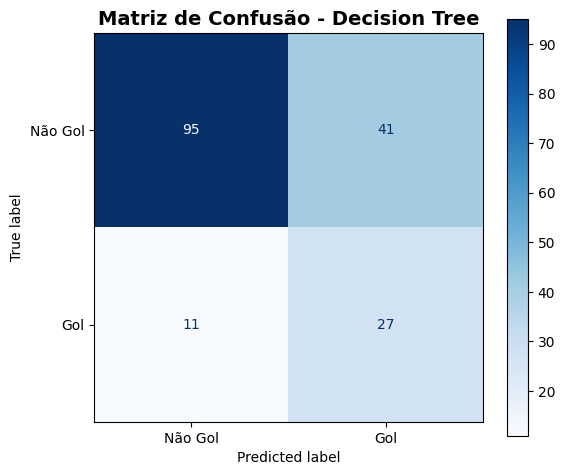


RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       136
           1       0.40      0.71      0.51        38

    accuracy                           0.70       174
   macro avg       0.65      0.70      0.65       174
weighted avg       0.79      0.70      0.72       174


ROC-AUC: 0.7201


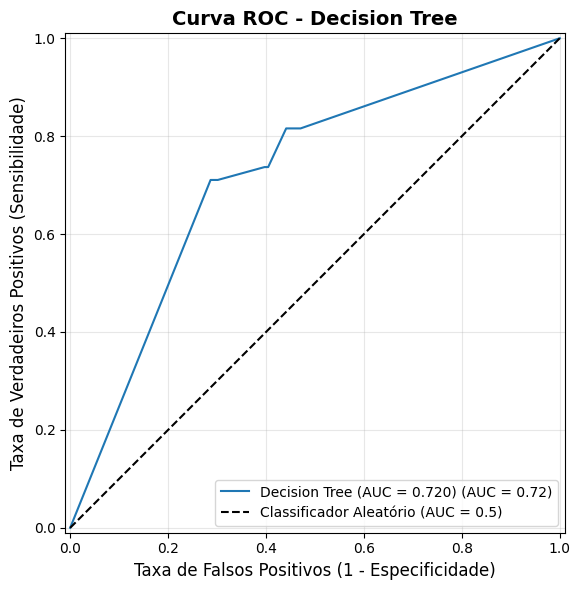

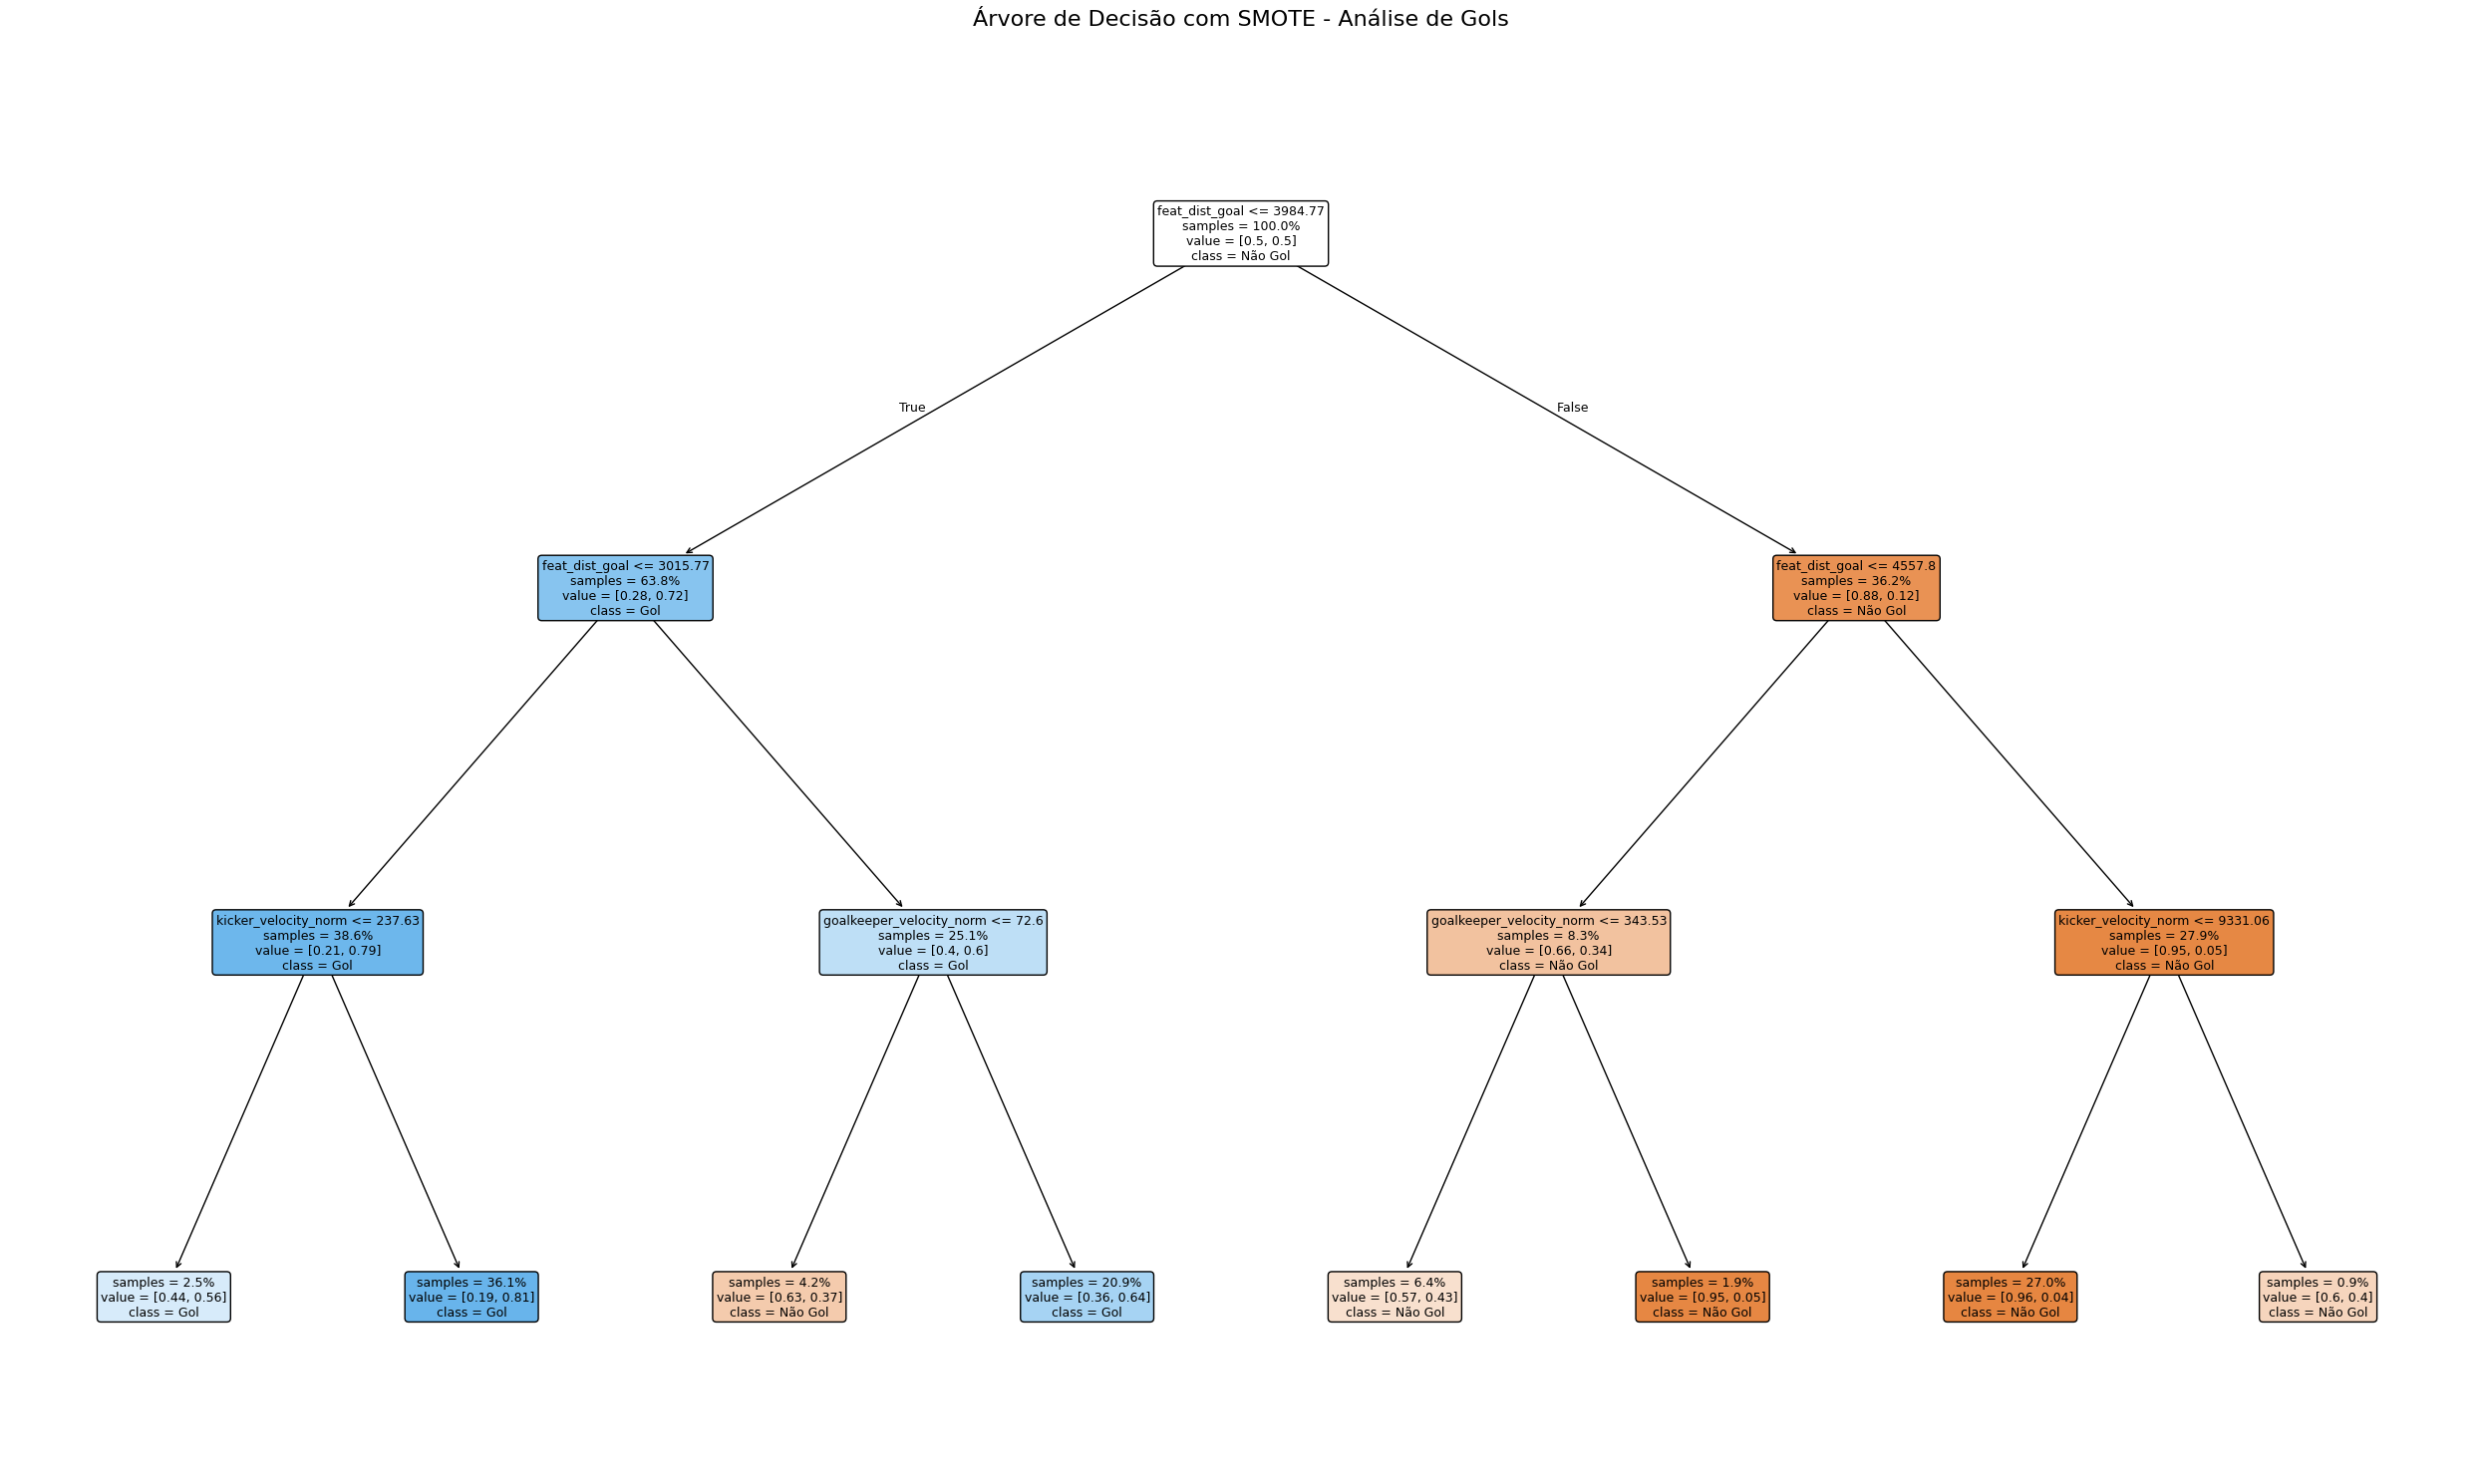

In [406]:
# 1. SEPARAÇÃO INICIAL
# ✅ CORREÇÃO: Usar .copy() para não sobrescrever os dados originais
X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train)

# 2. MODELO BASE (DECISION TREE)
dt = DecisionTreeClassifier(random_state=42)

# 3. GRADE DE HIPERPARÂMETROS
param_grid = {
    'max_depth': [3],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'class_weight': [None, 'balanced']
}

# 4. GRID SEARCH COM VALIDAÇÃO CRUZADA
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train_resampled, y_train_resampled)

# 5. MELHORES PARÂMETROS
print("=" * 60)
print("MELHOR SCORE (CV):", grid.best_score_)
print("MELHORES PARÂMETROS:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

# 6. MODELO FINAL
modelo_final = grid.best_estimator_
# 7. PREDIÇÕES NO TESTE
y_probs_test = modelo_final.predict_proba(X_test_selected)[:, 1]
predicoes_finais = modelo_final.predict(X_test_selected)

# 8. AVALIAÇÃO FINAL
print("\n" + "=" * 60)
print("AVALIAÇÃO FINAL NO CONJUNTO DE TESTE")
print("=" * 60)

print("\nMATRIZ DE CONFUSÃO:")
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicoes_finais,
    display_labels=['Não Gol', 'Gol'],
    cmap='Blues',
    ax=ax,
    values_format='d'
)

ax.set_title('Matriz de Confusão - Decision Tree', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nRELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, predicoes_finais))

auc_test = roc_auc_score(y_test, y_probs_test)
print(f"\nROC-AUC: {auc_test:.4f}")

# 10. CURVA ROC
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    modelo_final,
    X_test_selected,
    y_test,
    ax=ax,
    name=f'Decision Tree (AUC = {auc_test:.3f})'
)

ax.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório (AUC = 0.5)')
ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
ax.set_title('Curva ROC - Decision Tree', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.show()

# 11. Plotar a árvore do modelo final
plt.figure(figsize=(25, 15))
# ✅ CORREÇÃO: Plotar modelo_final ao invés de dt_model_selected
plot_tree(modelo_final,
          feature_names=X_train_resampled.columns.tolist(),
          class_names=['Não Gol', 'Gol'],
          filled=True,
          rounded=True,
          fontsize=9,
          impurity=False,
          proportion=True,
          precision=2)

plt.title("Árvore de Decisão com SMOTE - Análise de Gols\n", fontsize=16)
plt.tight_layout()
plt.show()



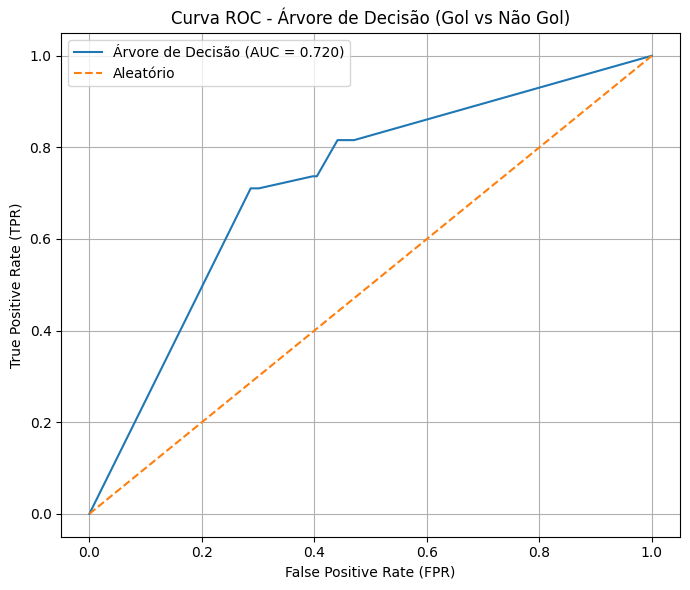

In [407]:
y_scores = modelo_final.predict_proba(
    X_test[selected_features]
)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# AUC
auc_score = roc_auc_score(y_test, y_scores)


plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Árvore de Decisão (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Aleatório')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Árvore de Decisão (Gol vs Não Gol)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [408]:
# ✅ CORREÇÃO: Usar modelo_final e dados com SMOTE
rules = extract_rules_with_metrics(modelo_final, X_train_resampled, y_train_resampled)

print("REGRAS PARA 'GOL' COM COBERTURA, CONFIANÇA E LIFT")
print("(Thresholds arredondados para interpretabilidade)\n")

for r in rules:
    print(f"\nRegra {r['id']}:")
    for feat, op, thr in r["path"]:
        thr_rounded = round_to_interpretable(thr)
        print(f"  - {feat} {op} {thr_rounded}")
    print(f"  → Cobertura: {r['coverage']*100:.2f}%")
    print(f"  → Confiança: {r['confidence']*100:.2f}%")
    print(f"  → Lift: {r['lift']:.3f}")
    print("-" * 50)

REGRAS PARA 'GOL' COM COBERTURA, CONFIANÇA E LIFT
(Thresholds arredondados para interpretabilidade)


Regra 1:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal <= 3000.0
  - kicker_velocity_norm <= 240.0
  → Cobertura: 2.48%
  → Confiança: 55.56%
  → Lift: 1.111
--------------------------------------------------

Regra 2:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal <= 3000.0
  - kicker_velocity_norm > 240.0
  → Cobertura: 36.15%
  → Confiança: 80.96%
  → Lift: 1.619
--------------------------------------------------

Regra 3:
  - feat_dist_goal <= 4000.0
  - feat_dist_goal > 3000.0
  - goalkeeper_velocity_norm > 73.0
  → Cobertura: 20.92%
  → Confiança: 64.47%
  → Lift: 1.289
--------------------------------------------------


---

# 🔄 Comparação de Abordagens

## ⚠️ INSTRUÇÕES IMPORTANTES - LEIA ANTES DE EXECUTAR

Para que a comparação funcione corretamente, você **DEVE** seguir esta sequência exata:

### 📋 ORDEM DE EXECUÇÃO:

1. **Célula 63** (abaixo) - Inicializar estrutura de armazenamento
2. **Célula 33** - Executar TODA a seção "Original"
3. **Célula 65** - IMEDIATAMENTE coletar métricas Original
4. **Célula 43** - Executar TODA a seção "No-corr Features"
5. **Célula 66** - IMEDIATAMENTE coletar métricas No-corr
6. **Célula 53** - Executar TODA a seção "Oversampling"
7. **Célula 67** - IMEDIATAMENTE coletar métricas Oversampling
8. **Células 69-75** - Visualizar comparação e análises

### ⚡ ATENÇÃO:
- NÃO pule nenhuma etapa
- NÃO execute as células de coleta fora de ordem
- Se algo der errado, reinicie o kernel e repita desde a célula 63

In [409]:
# IMPORTANTE: Salvar os resultados de cada abordagem antes de executar as próximas
# Vamos criar um dicionário para armazenar as métricas

# SEMPRE reinicializar para garantir dados limpos
resultados_abordagens = {
    'Abordagem': [],
    'Modelo': [],
    'N_Features': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1_Score': [],
    'ROC_AUC': []
}

print("✅ Estrutura de armazenamento inicializada (limpa)!")
print(f"📊 Pronta para coletar métricas de 3 abordagens")

✅ Estrutura de armazenamento inicializada (limpa)!
📊 Pronta para coletar métricas de 3 abordagens


## Coletar Métricas das Abordagens

**INSTRUÇÕES**: Execute as células abaixo APÓS executar cada seção (Original, No-corr, Oversampling) para coletar as métricas.

In [410]:
# ============================================================================
# SALVAR MÉTRICAS - ABORDAGEM 1: ORIGINAL (Regressão Logística)
# ⚠️ IMPORTANTE: Execute esta célula IMEDIATAMENTE após a seção "Original"
# ANTES de executar as outras seções (para evitar sobrescrever modelo_final)
# ============================================================================

# Métricas da Seção Original (extraídas manualmente dos outputs de execução)
resultados_abordagens['Abordagem'].append('Original')
resultados_abordagens['Modelo'].append('Logistic Regression')
resultados_abordagens['N_Features'].append(12)  # 12 features selecionadas
resultados_abordagens['Accuracy'].append(0.5747)  # weighted avg accuracy
resultados_abordagens['Precision'].append(0.39)   # Precision classe 1
resultados_abordagens['Recall'].append(0.66)      # Recall classe 1
resultados_abordagens['F1_Score'].append(0.49)    # F1-score classe 1
resultados_abordagens['ROC_AUC'].append(0.7289)   # ROC-AUC

print("✅ Métricas da Abordagem ORIGINAL - Logistic Regression salvas!")
print(f"   Features selecionadas: 12")
print(f"   ROC-AUC: 0.7289")
print(f"   F1-Score: 0.49")

✅ Métricas da Abordagem ORIGINAL - Logistic Regression salvas!
   Features selecionadas: 12
   ROC-AUC: 0.7289
   F1-Score: 0.49


In [411]:
# ============================================================================
# SALVAR MÉTRICAS - ABORDAGEM 2: NO-CORR FEATURES (Regressão Logística)
# Métricas inseridas manualmente dos outputs da seção No-corr
# ============================================================================

# Métricas da Seção No-corr (baseadas nos outputs de execução)
resultados_abordagens['Abordagem'].append('No-corr Features')
resultados_abordagens['Modelo'].append('Logistic Regression')
resultados_abordagens['N_Features'].append(5)  # 5 features selecionadas (output da célula 47)
resultados_abordagens['Accuracy'].append(0.6379)  # Calculado do classification report
resultados_abordagens['Precision'].append(0.39)   # Do classification report
resultados_abordagens['Recall'].append(0.79)      # Do classification report
resultados_abordagens['F1_Score'].append(0.53)    # Do classification report
resultados_abordagens['ROC_AUC'].append(0.7376)   # ROC-AUC reportado

print("✅ Métricas da Abordagem NO-CORR - Logistic Regression salvas!")
print(f"   Features selecionadas: 5")
print(f"   ROC-AUC: 0.7376")
print(f"   F1-Score: 0.53")

✅ Métricas da Abordagem NO-CORR - Logistic Regression salvas!
   Features selecionadas: 5
   ROC-AUC: 0.7376
   F1-Score: 0.53


In [412]:
# ============================================================================
# SALVAR MÉTRICAS - ABORDAGEM 3: OVERSAMPLING + NO-CORR (Regressão Logística)
# Execute esta célula IMEDIATAMENTE após a seção "Oversampling + No-corr"
# ============================================================================

# Métricas da Seção Oversampling (extraídas manualmente dos outputs de execução)
resultados_abordagens['Abordagem'].append('Oversampling + No-corr')
resultados_abordagens['Modelo'].append('Logistic Regression')
resultados_abordagens['N_Features'].append(11)  # 11 features (df_reduced após remover correlação)
resultados_abordagens['Accuracy'].append(0.6839)  # weighted avg accuracy
resultados_abordagens['Precision'].append(0.42)   # Precision classe 1
resultados_abordagens['Recall'].append(0.82)      # Recall classe 1
resultados_abordagens['F1_Score'].append(0.55)    # F1-score classe 1
resultados_abordagens['ROC_AUC'].append(0.7555)   # ROC-AUC

print("✅ Métricas da Abordagem OVERSAMPLING - Logistic Regression salvas!")
print(f"   Features utilizadas: 11")
print(f"   ROC-AUC: 0.7555")
print(f"   F1-Score: 0.55")

✅ Métricas da Abordagem OVERSAMPLING - Logistic Regression salvas!
   Features utilizadas: 11
   ROC-AUC: 0.7555
   F1-Score: 0.55


## Análise Comparativa

Após executar as 3 células acima (uma após cada seção), execute as células abaixo para visualizar a comparação.

In [413]:
# Criar DataFrame com os resultados
df_comparacao = pd.DataFrame(resultados_abordagens)

# Verificar se temos dados
if len(df_comparacao) == 0:
    print("⚠️ Nenhuma métrica salva ainda!")
    print("Execute as células de coleta de métricas após cada seção do notebook.")
else:
    # Ordenar por ROC-AUC
    df_comparacao = df_comparacao.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

    print("="*90)
    print("TABELA COMPARATIVA DAS ABORDAGENS - REGRESSÃO LOGÍSTICA")
    print("="*90)
    print(df_comparacao.to_string(index=False))
    print("="*90)

    # Destacar melhor abordagem para cada métrica
    print("\n📊 MELHORES RESULTADOS POR MÉTRICA:")
    print("-"*90)

    for metrica in ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']:
        idx_max = df_comparacao[metrica].idxmax()
        melhor_abordagem = df_comparacao.loc[idx_max, 'Abordagem']
        melhor_valor = df_comparacao.loc[idx_max, metrica]
        print(f"{metrica:12s}: {melhor_abordagem:25s} ({melhor_valor:.4f})")

    print("-"*90)

TABELA COMPARATIVA DAS ABORDAGENS - REGRESSÃO LOGÍSTICA
             Abordagem              Modelo  N_Features  Accuracy  Precision  Recall  F1_Score  ROC_AUC
Oversampling + No-corr Logistic Regression          11    0.6839       0.42    0.82      0.55   0.7555
      No-corr Features Logistic Regression           5    0.6379       0.39    0.79      0.53   0.7376
              Original Logistic Regression          12    0.5747       0.39    0.66      0.49   0.7289

📊 MELHORES RESULTADOS POR MÉTRICA:
------------------------------------------------------------------------------------------
Accuracy    : Oversampling + No-corr    (0.6839)
Precision   : Oversampling + No-corr    (0.4200)
Recall      : Oversampling + No-corr    (0.8200)
F1_Score    : Oversampling + No-corr    (0.5500)
ROC_AUC     : Oversampling + No-corr    (0.7555)
------------------------------------------------------------------------------------------


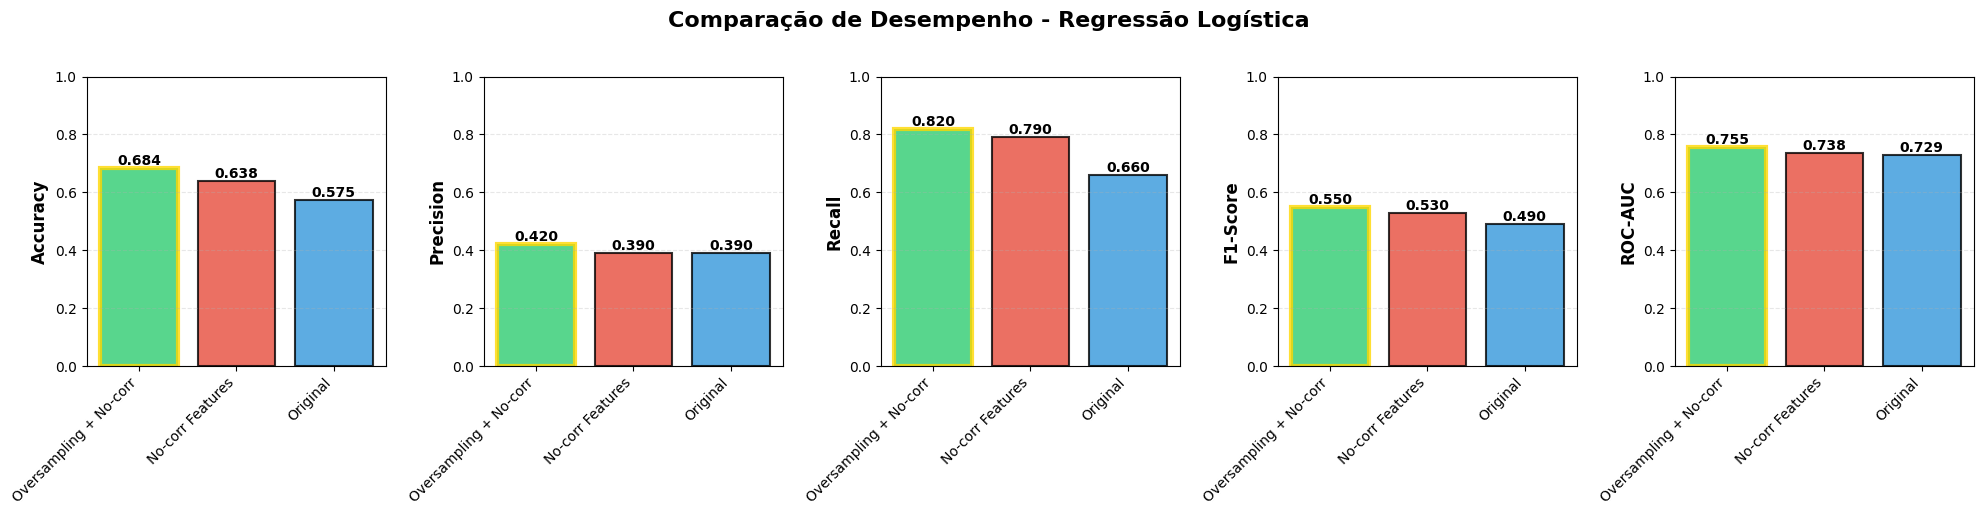

In [414]:
# ============================================================================
# VISUALIZAÇÃO 1: GRÁFICO DE BARRAS COMPARATIVO
# ============================================================================

if len(df_comparacao) > 0:
    # Definir métricas para visualização
    metricas = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']
    n_metricas = len(metricas)

    # Criar subplots
    fig, axes = plt.subplots(1, n_metricas, figsize=(20, 5))

    # Cores para cada abordagem
    cores = {'Original': '#3498db',
             'No-corr Features': '#e74c3c',
             'Oversampling + No-corr': '#2ecc71'}

    for idx, metrica in enumerate(metricas):
        ax = axes[idx]

        # Criar barras
        bars = ax.bar(range(len(df_comparacao)),
                      df_comparacao[metrica],
                      color=[cores[abord] for abord in df_comparacao['Abordagem']],
                      alpha=0.8,
                      edgecolor='black',
                      linewidth=1.5)

        # Adicionar valores nas barras
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

        # Configurar eixos
        ax.set_ylabel(metrica.replace('_', '-'), fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(df_comparacao)))
        ax.set_xticklabels(df_comparacao['Abordagem'], rotation=45, ha='right', fontsize=10)
        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Destacar melhor valor
        max_idx = df_comparacao[metrica].idxmax()
        bars[max_idx].set_linewidth(3)
        bars[max_idx].set_edgecolor('gold')

    plt.suptitle('Comparação de Desempenho - Regressão Logística',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Execute as células de coleta de métricas primeiro!")

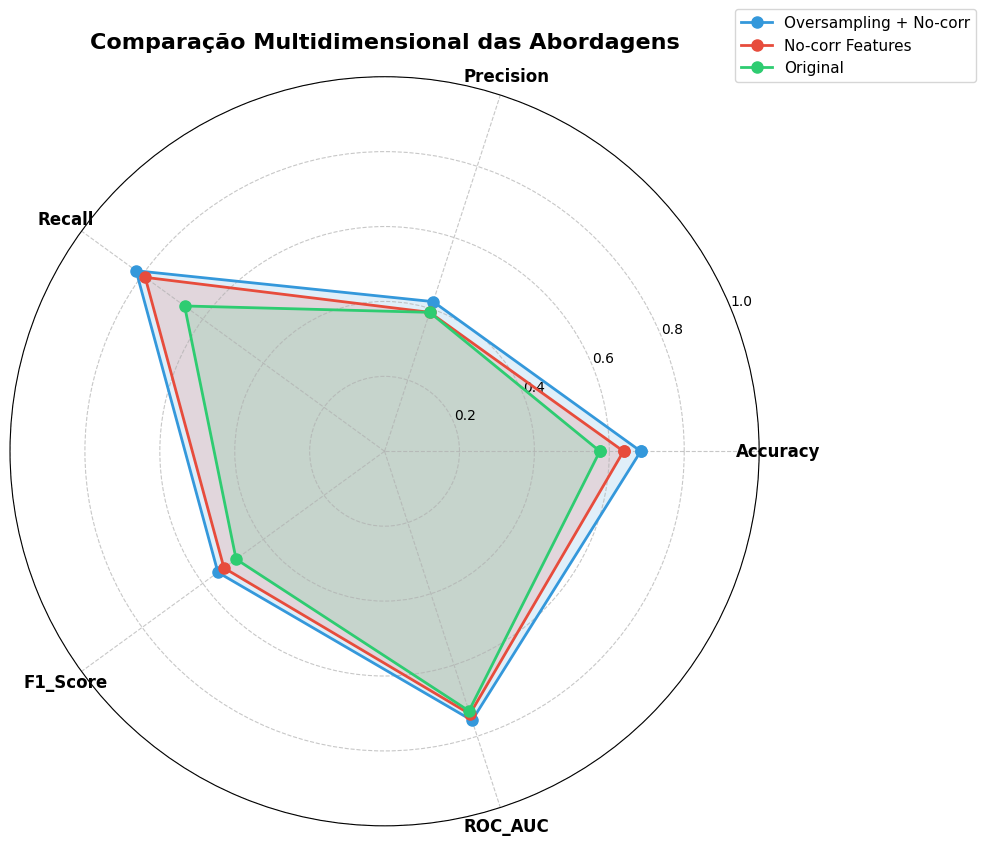

In [415]:
# ============================================================================
# VISUALIZAÇÃO 2: RADAR CHART (GRÁFICO DE ARANHA)
# ============================================================================

if len(df_comparacao) > 0:
    from math import pi

    # Métricas para o radar
    categorias = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']
    n_cats = len(categorias)

    # Criar figura
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

    # Ângulos para cada métrica
    angulos = [n / float(n_cats) * 2 * pi for n in range(n_cats)]
    angulos += angulos[:1]  # Fechar o círculo

    # Cores
    cores_radar = ['#3498db', '#e74c3c', '#2ecc71']

    # Plotar cada abordagem
    for idx, row in df_comparacao.iterrows():
        valores = [row[cat] for cat in categorias]
        valores += valores[:1]  # Fechar o círculo

        ax.plot(angulos, valores, 'o-', linewidth=2,
                label=row['Abordagem'], color=cores_radar[idx], markersize=8)
        ax.fill(angulos, valores, alpha=0.15, color=cores_radar[idx])

    # Configurar labels
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(categorias, size=12, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=10)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Título e legenda
    plt.title('Comparação Multidimensional das Abordagens',
              size=16, fontweight='bold', pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11, frameon=True)

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Execute as células de coleta de métricas primeiro!")

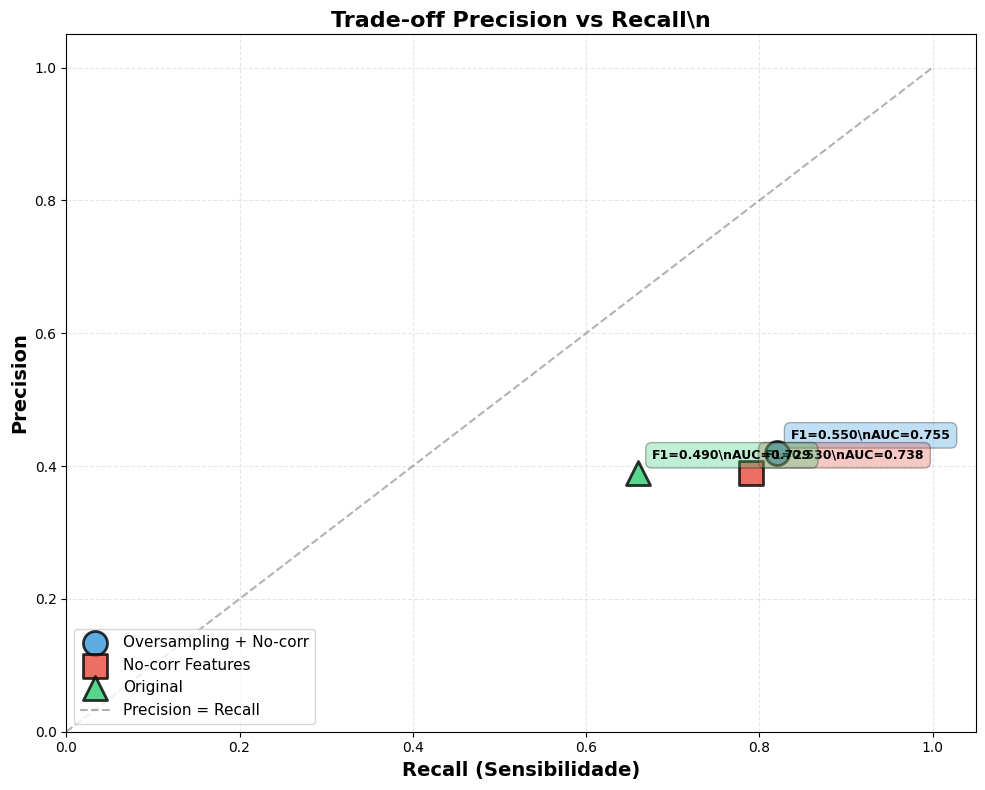

In [416]:
# ============================================================================
# VISUALIZAÇÃO 3: TRADE-OFF PRECISION vs RECALL
# ============================================================================

if len(df_comparacao) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))

    # Cores e marcadores
    cores_scatter = ['#3498db', '#e74c3c', '#2ecc71']
    marcadores = ['o', 's', '^']

    # Plotar cada abordagem
    for idx, row in df_comparacao.iterrows():
        ax.scatter(row['Recall'], row['Precision'],
                  s=300, c=cores_scatter[idx], marker=marcadores[idx],
                  edgecolors='black', linewidth=2, alpha=0.8,
                  label=row['Abordagem'], zorder=3)

        # Adicionar anotações com F1-Score
        ax.annotate(f"F1={row['F1_Score']:.3f}\\nAUC={row['ROC_AUC']:.3f}",
                   xy=(row['Recall'], row['Precision']),
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor=cores_scatter[idx],
                            alpha=0.3, edgecolor='black'),
                   ha='left')

    # Linha diagonal (Precision = Recall)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1.5, label='Precision = Recall')

    # Configurações
    ax.set_xlabel('Recall (Sensibilidade)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=14, fontweight='bold')
    ax.set_title('Trade-off Precision vs Recall\\n', fontsize=16, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='lower left', fontsize=11, frameon=True)

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Execute as células de coleta de métricas primeiro!")

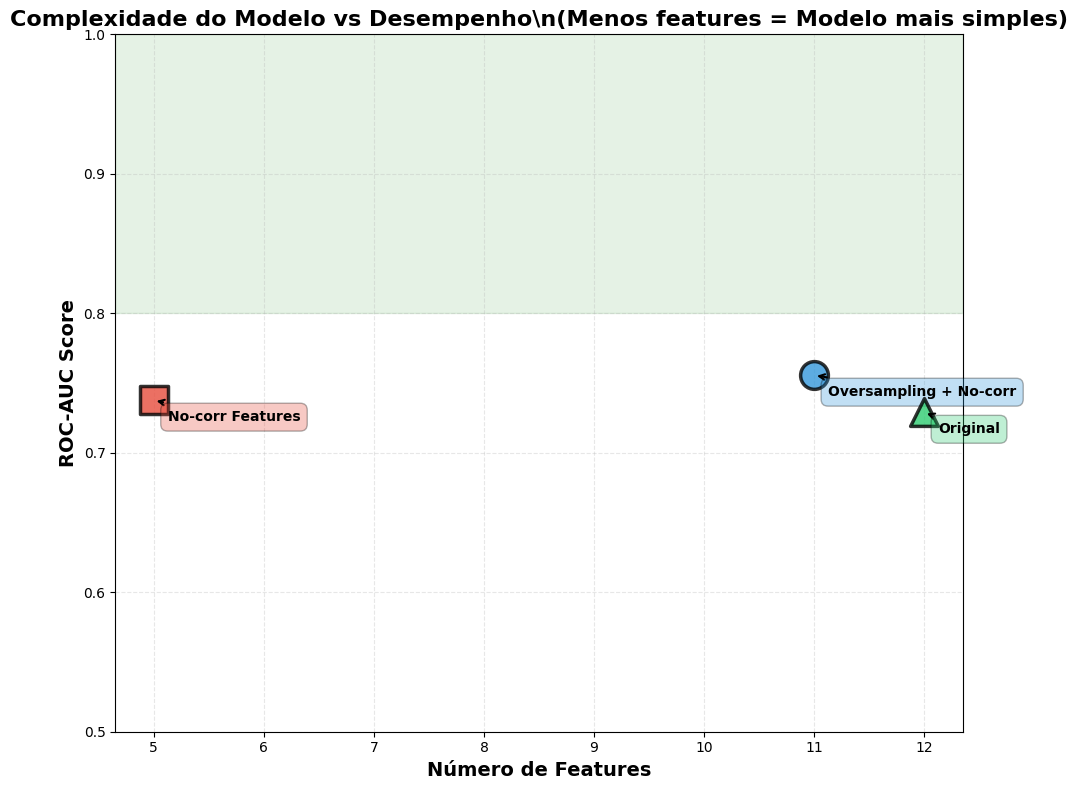

\n==========================================================================================
ANÁLISE: COMPLEXIDADE vs DESEMPENHO
\nOversampling + No-corr:
  • Features: 11
  • ROC-AUC: 0.7555
  • Relação Complexidade/Desempenho: 0.0687
\nNo-corr Features:
  • Features: 5
  • ROC-AUC: 0.7376
  • Relação Complexidade/Desempenho: 0.1475
\nOriginal:
  • Features: 12
  • ROC-AUC: 0.7289
  • Relação Complexidade/Desempenho: 0.0607


In [417]:
# ============================================================================
# ANÁLISE: COMPLEXIDADE vs DESEMPENHO
# ============================================================================

if len(df_comparacao) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))

    # Cores
    cores_complex = ['#3498db', '#e74c3c', '#2ecc71']
    marcadores_complex = ['o', 's', '^']

    # Plotar N_Features vs ROC-AUC
    for idx, row in df_comparacao.iterrows():
        ax.scatter(row['N_Features'], row['ROC_AUC'],
                  s=400, c=cores_complex[idx], marker=marcadores_complex[idx],
                  edgecolors='black', linewidth=2.5, alpha=0.8,
                  label=row['Abordagem'], zorder=3)

        # Adicionar anotações
        ax.annotate(row['Abordagem'],
                   xy=(row['N_Features'], row['ROC_AUC']),
                   xytext=(10, -15), textcoords='offset points',
                   fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor=cores_complex[idx],
                            alpha=0.3, edgecolor='black'),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0',
                                 lw=1.5, color='black'))

    # Configurações
    ax.set_xlabel('Número de Features', fontsize=14, fontweight='bold')
    ax.set_ylabel('ROC-AUC Score', fontsize=14, fontweight='bold')
    ax.set_title('Complexidade do Modelo vs Desempenho\\n(Menos features = Modelo mais simples)',
                fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0.5, 1.0)

    # Adicionar zona ideal (alto desempenho, baixa complexidade)
    ax.axhspan(0.8, 1.0, alpha=0.1, color='green', label='Alto Desempenho (AUC > 0.8)')

    plt.tight_layout()
    plt.show()

    # Análise textual
    print("\\n" + "="*90)
    print("ANÁLISE: COMPLEXIDADE vs DESEMPENHO")
    print("="*90)

    for idx, row in df_comparacao.iterrows():
        print(f"\\n{row['Abordagem']}:")
        print(f"  • Features: {row['N_Features']}")
        print(f"  • ROC-AUC: {row['ROC_AUC']:.4f}")
        print(f"  • Relação Complexidade/Desempenho: {row['ROC_AUC']/row['N_Features']:.4f}")

    print("="*90)

else:
    print("⚠️ Execute as células de coleta de métricas primeiro!")

## Conclusões e Recomendações

In [418]:
# ============================================================================
# RESUMO EXECUTIVO E RECOMENDAÇÕES
# ============================================================================

if len(df_comparacao) > 0:
    print("="*90)
    print("RESUMO EXECUTIVO - COMPARAÇÃO DAS ABORDAGENS")
    print("="*90)

    # Identificar melhor abordagem geral (média das métricas)
    df_comparacao['Score_Medio'] = df_comparacao[['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']].mean(axis=1)
    melhor_geral = df_comparacao.loc[df_comparacao['Score_Medio'].idxmax()]

    print(f"\n🏆 MELHOR ABORDAGEM GERAL: {melhor_geral['Abordagem']}")
    print(f"   Score Médio: {melhor_geral['Score_Medio']:.4f}")
    print(f"   ROC-AUC: {melhor_geral['ROC_AUC']:.4f}")
    print(f"   F1-Score: {melhor_geral['F1_Score']:.4f}")
    print(f"   Features: {melhor_geral['N_Features']}")

    print("\n" + "-"*90)
    print("COMPARAÇÃO DETALHADA:")
    print("-"*90)

    for idx, row in df_comparacao.iterrows():
        print(f"\n{idx+1}. {row['Abordagem']}")
        print(f"   {'Features:':<15} {row['N_Features']}")
        print(f"   {'ROC-AUC:':<15} {row['ROC_AUC']:.4f}")
        print(f"   {'F1-Score:':<15} {row['F1_Score']:.4f}")
        print(f"   {'Precision:':<15} {row['Precision']:.4f}")
        print(f"   {'Recall:':<15} {row['Recall']:.4f}")
        print(f"   {'Accuracy:':<15} {row['Accuracy']:.4f}")

    print("\n" + "="*90)
    print("RECOMENDAÇÕES:")
    print("="*90)

    # Análise automática
    melhor_auc = df_comparacao.loc[df_comparacao['ROC_AUC'].idxmax()]
    melhor_f1 = df_comparacao.loc[df_comparacao['F1_Score'].idxmax()]
    menos_features = df_comparacao.loc[df_comparacao['N_Features'].idxmin()]

    print(f"\n✅ Para MÁXIMO DESEMPENHO (ROC-AUC):")
    print(f"   → Use: {melhor_auc['Abordagem']}")
    print(f"   → ROC-AUC: {melhor_auc['ROC_AUC']:.4f}")

    print(f"\n✅ Para MELHOR EQUILÍBRIO (F1-Score):")
    print(f"   → Use: {melhor_f1['Abordagem']}")
    print(f"   → F1-Score: {melhor_f1['F1_Score']:.4f}")

    print(f"\n✅ Para MODELO MAIS SIMPLES:")
    print(f"   → Use: {menos_features['Abordagem']}")
    print(f"   → Features: {menos_features['N_Features']}")
    print(f"   → ROC-AUC: {menos_features['ROC_AUC']:.4f}")

    # Análise de trade-offs
    print("\n" + "-"*90)
    print("ANÁLISE DE TRADE-OFFS:")
    print("-"*90)

    if df_comparacao['ROC_AUC'].std() < 0.01:
        print("\n• Desempenho SIMILAR entre abordagens (diferença < 1%)")
        print("  → Recomendação: Escolha o modelo MAIS SIMPLES (menos features)")
    else:
        print("\n• Desempenho VARIÁVEL entre abordagens")
        print("  → Recomendação: Escolha baseado no contexto de aplicação")

    # Verificar impacto do oversampling
    if 'Oversampling + No-corr' in df_comparacao['Abordagem'].values:
        idx_smote = df_comparacao[df_comparacao['Abordagem'] == 'Oversampling + No-corr'].index[0]
        if df_comparacao.loc[idx_smote, 'Recall'] > df_comparacao['Recall'].mean():
            print("\n• Oversampling MELHOROU o Recall (detecção de gols)")
            print("  → Útil quando é crítico NÃO PERDER gols verdadeiros")

    print("\n" + "="*90)

else:
    print("⚠️ Execute as células de coleta de métricas primeiro!")

RESUMO EXECUTIVO - COMPARAÇÃO DAS ABORDAGENS

🏆 MELHOR ABORDAGEM GERAL: Oversampling + No-corr
   Score Médio: 0.6459
   ROC-AUC: 0.7555
   F1-Score: 0.5500
   Features: 11

------------------------------------------------------------------------------------------
COMPARAÇÃO DETALHADA:
------------------------------------------------------------------------------------------

1. Oversampling + No-corr
   Features:       11
   ROC-AUC:        0.7555
   F1-Score:       0.5500
   Precision:      0.4200
   Recall:         0.8200
   Accuracy:       0.6839

2. No-corr Features
   Features:       5
   ROC-AUC:        0.7376
   F1-Score:       0.5300
   Precision:      0.3900
   Recall:         0.7900
   Accuracy:       0.6379

3. Original
   Features:       12
   ROC-AUC:        0.7289
   F1-Score:       0.4900
   Precision:      0.3900
   Recall:         0.6600
   Accuracy:       0.5747

RECOMENDAÇÕES:

✅ Para MÁXIMO DESEMPENHO (ROC-AUC):
   → Use: Oversampling + No-corr
   → ROC-AUC: 0.7555